In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 21.2 MB/s eta 0:00:00


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.7 MB/s eta 0:00:00


In [ ]:
import sys
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import requests
import bs4 as bs
from tqdm import tqdm
from IPython.display import clear_output
import time
import random
from sklearn.preprocessing import MinMaxScaler

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [ ]:
file_path = '/content/makam.xlsx'
df = pd.read_excel(file_path)

In [ ]:
df.tail(5)

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),TDS\n(mg/L),Salinity\n(g/L),DO\n(mg/L),Sensor Depth\n(m),pH,Chlorophyll\n(ug/L),Turbid\n(NTU)
538748,2024-07-25 22:00:00,30.72,260.0,166.5,0.12,3.27,2.02,0.0,6.70,49.64
538749,2024-07-25 22:10:00,30.71,260.0,166.4,0.12,3.35,2.06,0.0,5.86,40.77
538750,2024-07-25 22:20:00,30.71,258.0,165.5,0.12,3.24,2.10,0.0,2.97,55.74
538751,2024-07-25 22:30:00,30.71,258.0,165.3,0.12,3.30,2.13,0.0,5.18,47.67
538752,2024-07-25 22:40:00,30.72,258.0,165.4,0.12,3.33,2.16,0.0,5.48,48.79


In [ ]:
df = df.drop(['TDS\n(mg/L)'], axis=1)
df = df.drop(['Salinity\n(g/L)'], axis=1)
df = df.drop(['Sensor Depth\n(m)'], axis=1)
df = df.drop(['Chlorophyll\n(ug/L)'], axis=1)
df = df.drop(['Turbid\n(NTU)'], axis=1)

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
0,2014-04-28 14:40:00,28.93,0.0,7.87,9.34
1,2014-04-28 14:50:00,NaN,NaN,NaN,NaN
2,2014-04-28 15:00:00,NaN,NaN,NaN,NaN
3,2014-04-28 15:10:00,NaN,NaN,NaN,NaN
4,2014-04-28 15:20:00,NaN,NaN,NaN,NaN
...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.72,260.0,3.27,0.00
538749,2024-07-25 22:10:00,30.71,260.0,3.35,0.00
538750,2024-07-25 22:20:00,30.71,258.0,3.24,0.00
538751,2024-07-25 22:30:00,30.71,258.0,3.30,0.00


# **clean data**:

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,432899.000000,432899.000000,432899.000000,432899.000000
mean,2019-06-12 06:39:59.999998464,-78.213296,349.596384,-210.651016,-398.025160
min,2014-04-28 14:40:00,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,2016-11-18 22:40:00,29.140000,294.000000,1.630000,7.120000
50%,2019-06-12 06:40:00,30.550000,356.000000,2.720000,7.230000
75%,2022-01-02 14:40:00,31.410000,440.000000,3.600000,7.340000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,1037.028654,1173.119092,1445.086492,1972.434922


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),105854
Conductivity\n(uS/cm),105854
DO\n(mg/L),105854
pH,105854


In [ ]:
# ตรวจสอบค่า -9999 ในทุกคอลัมน์
neg9999_counts = (df == -9999).sum()
print(neg9999_counts)

date_time                    0
Temperature\n(֯C)         4679
Conductivity\n(uS/cm)     4658
DO\n(mg/L)                9234
pH                       17531
dtype: int64


In [ ]:
df = df.replace(-9999, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,428220.000000,428241.000000,423665.000000,415368.000000
mean,2019-06-12 06:39:59.999998464,30.187435,462.158614,2.691163,7.193080
min,2014-04-28 14:40:00,0.000000,-3999.000000,0.000000,-26.300000
25%,2016-11-18 22:40:00,29.190000,297.000000,1.730000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.760000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.620000,7.350000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,2.339895,462.215793,1.578567,0.650542


In [ ]:
# ตรวจสอบค่า 0 ในทุกคอลัมน์
zero_counts = (df == 0).sum()
print(zero_counts)

date_time                    0
Temperature\n(֯C)          597
Conductivity\n(uS/cm)     2263
DO\n(mg/L)               42510
pH                        2794
dtype: int64


In [ ]:
df = df.replace(0, np.nan)

In [ ]:
zero_counts = (df == 50.840000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(50.840000, np.nan)

In [ ]:
zero_counts = (df == -26.300000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(-26.300000, np.nan)

In [ ]:
zero_counts = (df == -3999.000000).sum()
print(zero_counts)

date_time                 0
Temperature\n(֯C)         0
Conductivity\n(uS/cm)    87
DO\n(mg/L)                0
pH                        0
dtype: int64


In [ ]:
df = df.replace(-3999.000000, np.nan)

In [ ]:
zero_counts = (df == 99.990000).sum()
print(zero_counts)

date_time                  0
Temperature\n(֯C)        105
Conductivity\n(uS/cm)      0
DO\n(mg/L)                 0
pH                         0
dtype: int64


In [ ]:
df = df.replace(99.990000, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425891.000000,381155.000000,412572.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.525639,2.991307,7.241768
min,2014-04-28 14:40:00,12.830000,1.000000,0.010000,-15.340000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.832389,1.368198,0.256849


In [ ]:
df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
df['pH'][df['pH'] < 1] = np.nan

<ipython-input-72-096c18d0bb55>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
<ipython-input-72-096c18d0bb55>:1: SettingWithCopyWarning: 
A value is trying to be set 

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412556.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.242067
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.834400,1.368198,0.251171


In [ ]:
df['pH'][df['pH'] > 14] = np.nan

<ipython-input-74-796f110e6a72>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pH'][df['pH'] > 14] = np.nan
<ipython-input-74-796f110e6a72>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame



In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412552.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.241943
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.736159,457.834400,1.368198,0.247345


In [ ]:
df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
df['Conductivity\n(uS/cm)'].interpolate(method='linear', inplace=True)
df['DO\n(mg/L)'].interpolate(method='linear', inplace=True)
df['pH'].interpolate(method='linear', inplace=True)

<ipython-input-76-b4db06670e76>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
<ipython-input-76-b4db06670e76>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,536313.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.000000,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,524.967900,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,426.525651,1.217890,0.353856


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),2440
DO\n(mg/L),0
pH,0


In [ ]:
df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)

<ipython-input-79-0624677d0968>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),0
DO\n(mg/L),0
pH,0


In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,538753.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.654009,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,523.263959,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,425.558691,1.217890,0.353856


In [ ]:
# แปลงคอลัมน์ date_time เป็น datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
0,2014-04-28 14:40:00,28.930000,501.199898,7.870000,9.340000
1,2014-04-28 14:50:00,28.933946,501.199898,7.865893,9.337691
2,2014-04-28 15:00:00,28.937893,501.199898,7.861785,9.335383
3,2014-04-28 15:10:00,28.941839,501.199898,7.857678,9.333074
4,2014-04-28 15:20:00,28.945785,501.199898,7.853570,9.330765
...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.720000,260.000000,3.270000,3.080000
538749,2024-07-25 22:10:00,30.710000,260.000000,3.350000,3.080000
538750,2024-07-25 22:20:00,30.710000,258.000000,3.240000,3.080000
538751,2024-07-25 22:30:00,30.710000,258.000000,3.300000,3.080000


In [ ]:
df = df.set_index('date_time')

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
date_time,,,,
2014-04-28 14:40:00,28.930000,501.199898,7.870000,9.340000
2014-04-28 14:50:00,28.933946,501.199898,7.865893,9.337691
2014-04-28 15:00:00,28.937893,501.199898,7.861785,9.335383
2014-04-28 15:10:00,28.941839,501.199898,7.857678,9.333074
2014-04-28 15:20:00,28.945785,501.199898,7.853570,9.330765
...,...,...,...,...
2024-07-25 22:00:00,30.720000,260.000000,3.270000,3.080000
2024-07-25 22:10:00,30.710000,260.000000,3.350000,3.080000
2024-07-25 22:20:00,30.710000,258.000000,3.240000,3.080000


In [ ]:
df = df.resample('D').mean()

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
date_time,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510
2014-04-29,29.433154,501.199898,7.346309,9.045638
2014-04-30,30.001423,501.199898,6.754846,8.713181
2014-05-01,30.569691,501.199898,6.163383,8.380725
2014-05-02,31.137960,501.199898,5.571919,8.048268
...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000
2024-07-22,31.287986,345.090278,2.114375,3.080000
2024-07-23,31.137361,338.798611,2.126111,3.080000


## ใส่ข้อมูลย้อนหลังของข้อมูลต่างๆ7วัน

In [ ]:
def create_lag_features(df, column_name, max_lag):
    for lag in range(1, max_lag + 1):
        df[f'{column_name}_lag_{lag}'] = df[column_name].shift(lag)
    return df

In [ ]:
df = create_lag_features(df, 'Temperature\n(֯C)', 7)

In [ ]:
df = create_lag_features(df, 'Conductivity\n(uS/cm)', 7)

In [ ]:
df = create_lag_features(df, 'DO\n(mg/L)', 7)

In [ ]:
df = create_lag_features(df, 'pH', 7)

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,Temperature\n(֯C)_lag_1,Temperature\n(֯C)_lag_2,Temperature\n(֯C)_lag_3,Temperature\n(֯C)_lag_4,Temperature\n(֯C)_lag_5,Temperature\n(֯C)_lag_6,...,DO\n(mg/L)_lag_5,DO\n(mg/L)_lag_6,DO\n(mg/L)_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
date_time,,,,,,,,,,,,,,,,,,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-29,29.433154,501.199898,7.346309,9.045638,29.038523,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,9.276510,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-30,30.001423,501.199898,6.754846,8.713181,29.433154,29.038523,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,9.045638,9.276510,NaN,NaN,NaN,NaN,NaN
2014-05-01,30.569691,501.199898,6.163383,8.380725,30.001423,29.433154,29.038523,NaN,NaN,NaN,...,NaN,NaN,NaN,8.713181,9.045638,9.276510,NaN,NaN,NaN,NaN
2014-05-02,31.137960,501.199898,5.571919,8.048268,30.569691,30.001423,29.433154,29.038523,NaN,NaN,...,NaN,NaN,NaN,8.380725,8.713181,9.045638,9.27651,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000,31.311667,31.264444,31.348333,31.361736,31.442431,31.555000,...,2.706875,2.588125,2.585417,3.080000,3.080000,3.080000,3.08000,3.08,3.08,3.08
2024-07-22,31.287986,345.090278,2.114375,3.080000,31.365139,31.311667,31.264444,31.348333,31.361736,31.442431,...,2.654931,2.706875,2.588125,3.080000,3.080000,3.080000,3.08000,3.08,3.08,3.08
2024-07-23,31.137361,338.798611,2.126111,3.080000,31.287986,31.365139,31.311667,31.264444,31.348333,31.361736,...,2.618611,2.654931,2.706875,3.080000,3.080000,3.080000,3.08000,3.08,3.08,3.08


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.describe()

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,Temperature\n(֯C)_lag_1,Temperature\n(֯C)_lag_2,Temperature\n(֯C)_lag_3,Temperature\n(֯C)_lag_4,Temperature\n(֯C)_lag_5,Temperature\n(֯C)_lag_6,...,DO\n(mg/L)_lag_5,DO\n(mg/L)_lag_6,DO\n(mg/L)_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
count,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,...,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000
mean,30.082045,501.197132,2.958886,7.234540,30.082278,30.082469,30.082469,30.082277,30.081911,30.081408,...,2.963094,2.964452,2.965889,7.235749,7.236989,7.238320,7.239739,7.241247,7.242844,7.244503
std,1.605010,359.688885,1.104246,0.341453,1.605182,1.605329,1.605329,1.605227,1.605091,1.604999,...,1.108521,1.110782,1.113507,0.334666,0.327774,0.320908,0.314164,0.307642,0.301456,0.295533
min,20.238053,164.506944,0.233403,2.082611,20.238053,20.238053,20.238053,20.238053,20.238053,20.238053,...,0.233403,0.233403,0.233403,2.082611,2.082611,2.082611,2.082611,2.082611,2.082611,2.082611
25%,29.155264,318.267361,2.328314,7.160365,29.155264,29.155264,29.155264,29.155264,29.155264,29.155264,...,2.333437,2.333933,2.333933,7.160399,7.160450,7.160693,7.160972,7.161042,7.161042,7.161042
50%,30.205035,385.791667,2.904792,7.261667,30.205035,30.205035,30.205035,30.205035,30.204633,30.204097,...,2.907847,2.908403,2.908436,7.261667,7.261701,7.261806,7.261883,7.262083,7.262099,7.262153
75%,31.246146,540.576941,3.460035,7.339792,31.246771,31.247257,31.247257,31.246771,31.246146,31.245174,...,3.466076,3.469230,3.470827,7.339826,7.339896,7.339966,7.340035,7.340143,7.340234,7.340342
max,34.226458,4057.263889,7.837917,8.270000,34.226458,34.226458,34.226458,34.226458,34.226458,34.226458,...,7.837917,7.837917,7.837917,8.270000,8.270000,8.270000,8.380725,8.713181,9.045638,9.276510


#**Temp**

In [ ]:
X = df[['Temperature\n(֯C)_lag_1','Temperature\n(֯C)_lag_2','Temperature\n(֯C)_lag_3','Temperature\n(֯C)_lag_4','Temperature\n(֯C)_lag_5','Temperature\n(֯C)_lag_6','Temperature\n(֯C)_lag_7']]
y = df["Temperature\n(֯C)"]

In [ ]:
y

,Temperature\n(֯C)
date_time,
2014-05-05,31.747917
2014-05-06,31.799965
2014-05-07,31.775764
2014-05-08,31.948542
2014-05-09,32.087292
...,...
2024-07-21,31.365139
2024-07-22,31.287986
2024-07-23,31.137361


In [ ]:
X

,Temperature\n(֯C)_lag_1,Temperature\n(֯C)_lag_2,Temperature\n(֯C)_lag_3,Temperature\n(֯C)_lag_4,Temperature\n(֯C)_lag_5,Temperature\n(֯C)_lag_6,Temperature\n(֯C)_lag_7
date_time,,,,,,,
2014-05-05,31.693750,31.678415,31.137960,30.569691,30.001423,29.433154,29.038523
2014-05-06,31.747917,31.693750,31.678415,31.137960,30.569691,30.001423,29.433154
2014-05-07,31.799965,31.747917,31.693750,31.678415,31.137960,30.569691,30.001423
2014-05-08,31.775764,31.799965,31.747917,31.693750,31.678415,31.137960,30.569691
2014-05-09,31.948542,31.775764,31.799965,31.747917,31.693750,31.678415,31.137960
...,...,...,...,...,...,...,...
2024-07-21,31.311667,31.264444,31.348333,31.361736,31.442431,31.555000,31.562153
2024-07-22,31.365139,31.311667,31.264444,31.348333,31.361736,31.442431,31.555000
2024-07-23,31.287986,31.365139,31.311667,31.264444,31.348333,31.361736,31.442431


In [ ]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#X = scaler.fit_transform(X)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
X

,Temperature\n(֯C)_lag_1,Temperature\n(֯C)_lag_2,Temperature\n(֯C)_lag_3,Temperature\n(֯C)_lag_4,Temperature\n(֯C)_lag_5,Temperature\n(֯C)_lag_6,Temperature\n(֯C)_lag_7
date_time,,,,,,,
2014-05-05,0.818942,0.817846,0.779210,0.738586,0.697962,0.657337,0.629126
2014-05-06,0.822815,0.818942,0.817846,0.779210,0.738586,0.697962,0.657337
2014-05-07,0.826535,0.822815,0.818942,0.817846,0.779210,0.738586,0.697962
2014-05-08,0.824805,0.826535,0.822815,0.818942,0.817846,0.779210,0.738586
2014-05-09,0.837157,0.824805,0.826535,0.822815,0.818942,0.817846,0.779210
...,...,...,...,...,...,...,...
2024-07-21,0.791628,0.788252,0.794249,0.795207,0.800976,0.809023,0.809535
2024-07-22,0.795451,0.791628,0.788252,0.794249,0.795207,0.800976,0.809023
2024-07-23,0.789935,0.795451,0.791628,0.788252,0.794249,0.795207,0.800976


In [ ]:
y

,Temperature\n(֯C)
date_time,
2014-05-05,0.822815
2014-05-06,0.826535
2014-05-07,0.824805
2014-05-08,0.837157
2014-05-09,0.847076
...,...
2024-07-21,0.795451
2024-07-22,0.789935
2024-07-23,0.779167


In [ ]:
split_at = int(len(X) * 0.7)

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]


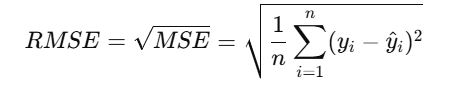




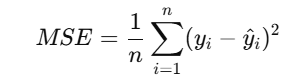






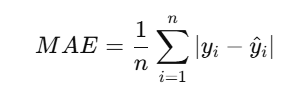








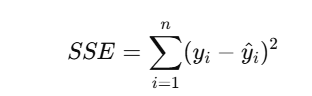



**note**

1. SSE (Sum of Squared Errors)ได้จากการนำเอาผลต่างระหว่างค่าที่ทำนายกับคำตอบจริงของแต่ละตัวอย่างมายกกำลังสอง แล้วนำมาบวกกันทั้งหมด (machine learning)
2. MAE (Mean Absolute Error) ได้จากการนำ SSE มาหารจำนวนตัวอย่าง
3. RMSE (Root Mean Square Error) คือ วิธีการวัดความแตกต่างระหว่างค่าที่คาดการณ์และค่าจริง โดยการหาค่ารากที่สองของค่าเฉลี่ยของความผิดพลาดกำลังสอง (squared errors)
4. MSE (Mean Squared Error) คือ วิธีการวัดความแตกต่างระหว่างค่าที่คาดการณ์และค่าจริง โดยจะคำนวณค่าผิดพลาดกำลังสอง (squared errors) และหาค่าเฉลี่ย



***SSE บ่งบอกถึงผลรวมของข้อผิดพลาดทั้งหมด หากมีจำนวนข้อมูลมาก ค่า SSE มักจะสูงได้โดยธรรมชาติ

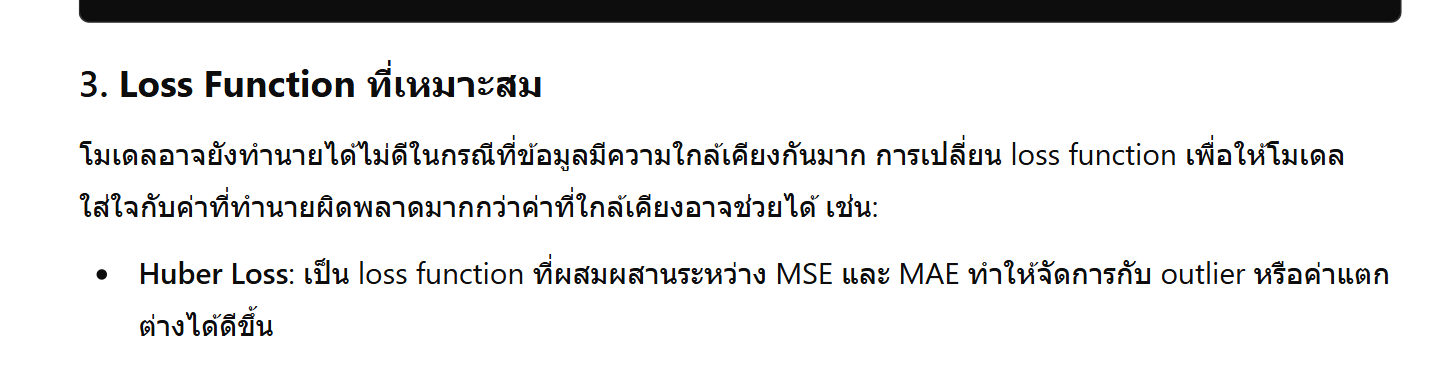

In [ ]:
# Objective function
def objective(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 3, 5),  # ลดความลึกนิดนึง
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
        'random_strength': trial.suggest_uniform('random_strength', 1, 10),  # เพิ่ม randomness
        'bagging_temperature': trial.suggest_uniform('bagging_temperature', 0.5, 1.5),  # ทำให้การสุ่มใน bootstrap หลากหลายขึ้น
        'border_count': trial.suggest_int('border_count', 64, 128),  # ปรับละเอียดระดับ bin split
        'loss_function': 'RMSE',
        'early_stopping_rounds': 20,
        'verbose': 0,
        'random_seed': 42
    }

    model = CatBoostRegressor(**param)
    model.fit(X_train1, y_train1,
              eval_set=(X_test1, y_test1),
              cat_features=cat_features,
              use_best_model=True)

    y_pred = model.predict(X_test1)
    mse = mean_squared_error(y_test1, y_pred)
    return mse

In [ ]:
# ประเมินผล
def regression_model(model, X_train, y_train, X_test, y_test, show_feature_importance=True):
    y_hat_train = model.predict(X_train)
    y_hat_test = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_hat_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_hat_test))
    mse = mean_squared_error(y_test, y_hat_test)
    test_r2 = r2_score(y_test, y_hat_test)

    print('\nTest set performance:')
    print(f'R2: {test_r2}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}\n')

    if show_feature_importance:
        feature_df = pd.DataFrame({
            "Feature": model.feature_names_,
            "Importance": model.get_feature_importance()
        }).sort_values(by="Importance", ascending=False)
        print("\nความสำคัญของตัวแปร:\n", feature_df)

    # แสดงกราฟ Loss
    if hasattr(model, 'get_evals_result'):
        evals_result = model.get_evals_result()
        train_loss = evals_result['learn']['RMSE']
        val_loss = evals_result['validation']['RMSE']
        plt.figure(figsize=(10, 5))
        plt.plot(train_loss, label='Train Loss')
        plt.plot(val_loss, label='Validation Loss')
        plt.title('Loss Curve: ตรวจสอบ Overfitting')
        plt.xlabel('Iterations')
        plt.ylabel('RMSE')
        plt.legend()
        plt.grid(True)
        plt.show()

## no**.1**

[I 2025-04-17 15:13:47,934] A new study created in memory with name: no-name-ceef57ff-7272-46b4-aad8-a3209db1eb17
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.1021630	test: 0.1287524	best: 0.1287524 (0)	total: 806us	remaining: 233ms
100:	learn: 0.0154495	test: 0.0365851	best: 0.0365851 (100)	total: 76.7ms	remaining: 144ms
200:	learn: 0.0117761	test: 0.0323535	best: 0.0323535 (200)	total: 163ms	remaining: 72.3ms
289:	learn: 0.0099561	test: 0.0307124	best: 0.0307124 (289)	total: 232ms	remaining: 0us

bestTest = 0.03071235505
bestIteration = 289


Test set performance:
R2: 0.9453876922655795
MAE: 0.014104535623235888
RMSE: 0.03071235491133112
MSE: 0.0009432487441995648


ความสำคัญของตัวแปร:
                    Feature  Importance
0  Temperature\n(֯C)_lag_1   34.435477
1  Temperature\n(֯C)_lag_2   19.230784
3  Temperature\n(֯C)_lag_4   12.054521
4  Temperature\n(֯C)_lag_5   11.518532
2  Temperature\n(֯C)_lag_3   11.066618
5  Temperature\n(֯C)_lag_6    7.238942
6  Temperature\n(֯C)_lag_7    4.455125


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

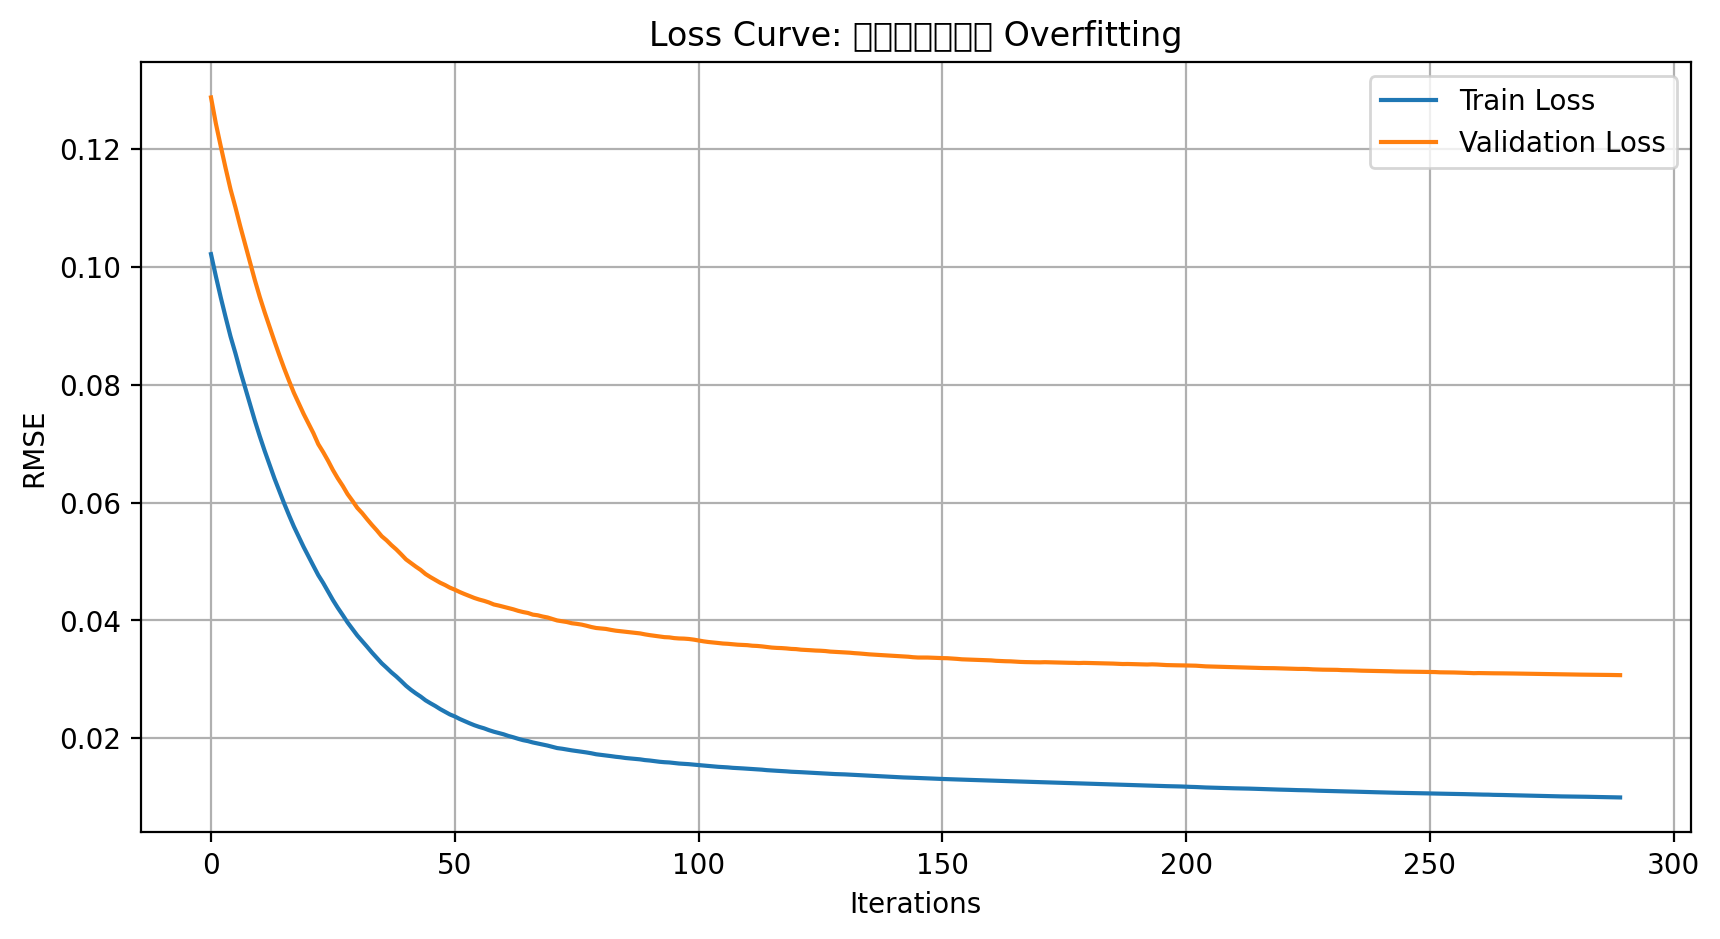

In [ ]:
import optuna
from optuna.samplers import TPESampler
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train1, y_train1,
                    eval_set=(X_test1, y_test1),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train1, y_train1, X_test1, y_test1)

## **test**

In [ ]:
# 1. ย้อนการสเกลของค่าที่ทำนายและค่าจริง
y_pred_scaled = model.predict(X_test1)
y_pred_original = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# สมมติว่าคุณมีค่าจริง y_test1 ที่ถูกสเกลไว้ด้วย คุณควรย้อนการแปลงค่าจริงเหล่านั้น
y_test_original = scaler.inverse_transform(y_test1)

# 2. สร้าง DataFrame เพื่อความสะดวกในการเปรียบเทียบ
results_df = pd.DataFrame({
    "Predicted": y_pred_original.flatten(),
    "Actual": y_test_original.flatten()
})

# 3. พิมพ์ผลลัพธ์การเปรียบเทียบ
print("การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:")
print(results_df)

การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:
      Predicted     Actual
0     31.663068  31.794583
1     31.778720  31.908611
2     31.903898  31.927465
3     31.912839  31.984792
4     31.981276  32.051875
...         ...        ...
1116  31.283275  31.365139
1117  31.357093  31.287986
1118  31.266566  31.137361
1119  31.184359  30.967847
1120  31.001245  30.821606

[1121 rows x 2 columns]


## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

[I 2025-04-17 15:20:52,002] A new study created in memory with name: no-name-b798ab90-97ac-4850-bcbe-40f62f2a5a18
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.1021358	test: 0.1288107	best: 0.1288107 (0)	total: 1.2ms	remaining: 346ms
100:	learn: 0.0156715	test: 0.0368459	best: 0.0368459 (100)	total: 118ms	remaining: 221ms
200:	learn: 0.0118918	test: 0.0323242	best: 0.0323242 (200)	total: 299ms	remaining: 132ms
289:	learn: 0.0100791	test: 0.0307607	best: 0.0307593 (288)	total: 435ms	remaining: 0us

bestTest = 0.03075925753
bestIteration = 288

Shrink model to first 289 iterations.

Test set performance:
R2: 0.9452533882247112
MAE: 0.01411197612502932
RMSE: 0.030759257370084236
MSE: 0.0009461319139590814


ความสำคัญของตัวแปร:
                    Feature  Importance
0  Temperature\n(֯C)_lag_1   33.597857
1  Temperature\n(֯C)_lag_2   17.926375
2  Temperature\n(֯C)_lag_3   12.960100
4  Temperature\n(֯C)_lag_5   11.415973
3  Temperature\n(֯C)_lag_4   10.999295
5  Temperature\n(֯C)_lag_6    6.765148
6  Temperature\n(֯C)_lag_7    6.335252


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

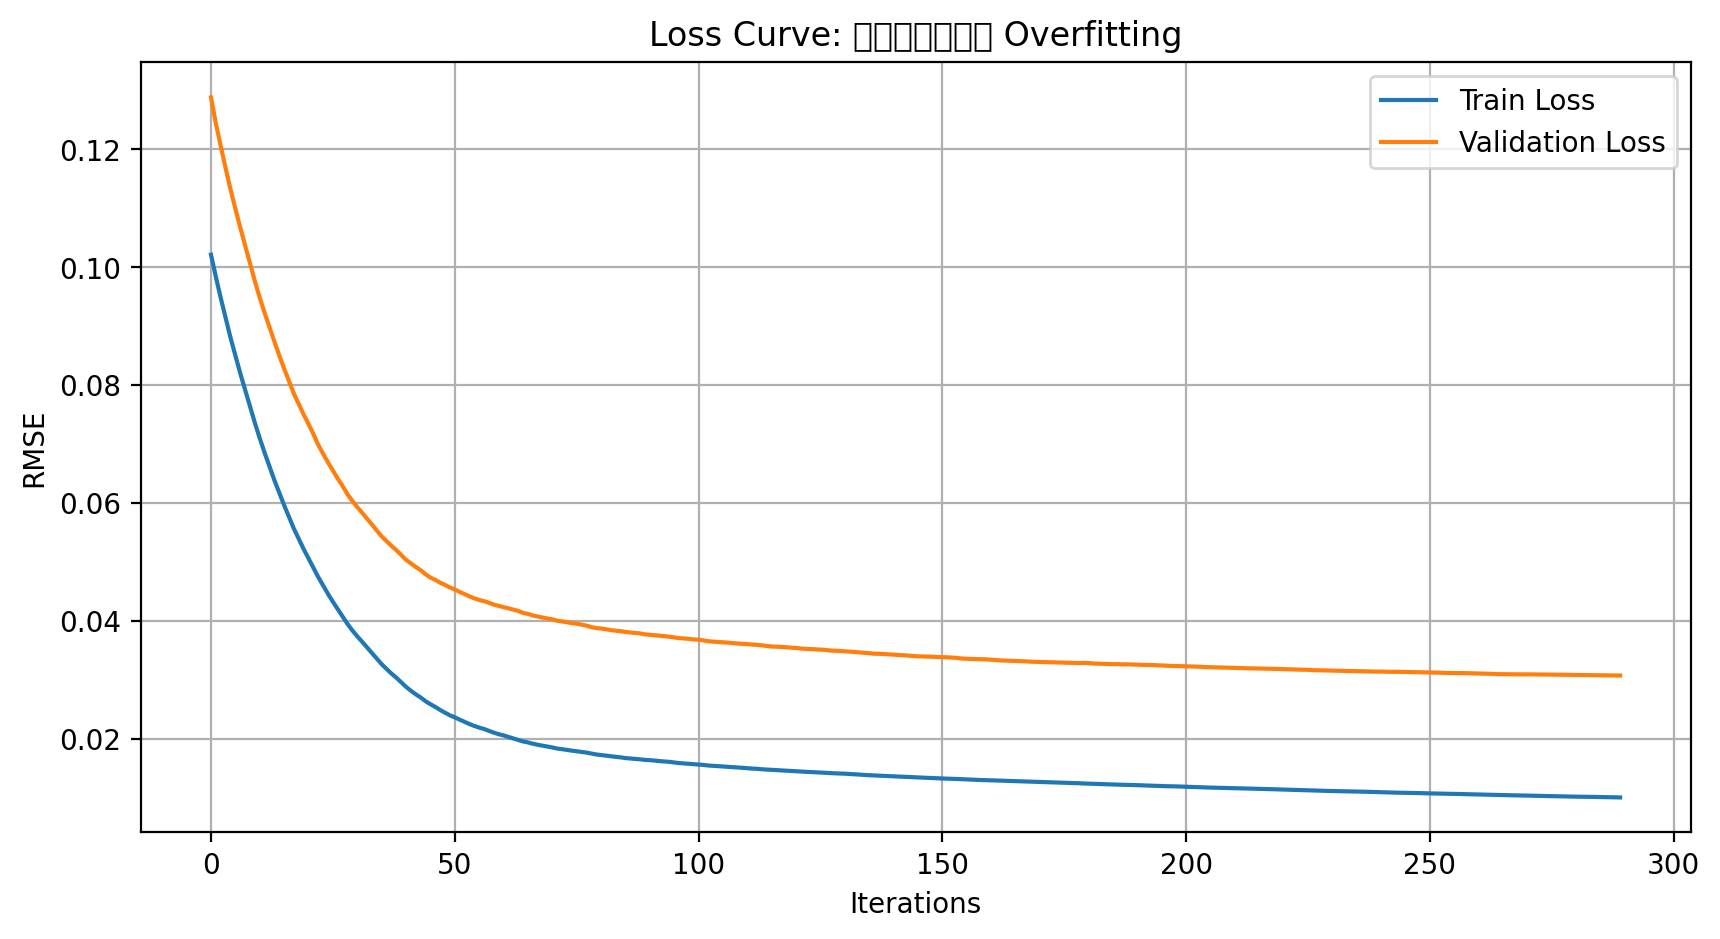

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train2, y_train2,
                    eval_set=(X_test2, y_test2),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train2, y_train2, X_test2, y_test2)

## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

[I 2025-04-17 15:20:19,595] A new study created in memory with name: no-name-bcef1f61-8972-420b-a2c9-20fd0ad0e3a5
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.1004009	test: 0.1324543	best: 0.1324543 (0)	total: 802us	remaining: 232ms
100:	learn: 0.0154687	test: 0.0375358	best: 0.0375358 (100)	total: 83.9ms	remaining: 157ms
200:	learn: 0.0116769	test: 0.0327042	best: 0.0327042 (200)	total: 155ms	remaining: 68.8ms
289:	learn: 0.0099212	test: 0.0310070	best: 0.0310070 (289)	total: 222ms	remaining: 0us

bestTest = 0.03100701485
bestIteration = 289


Test set performance:
R2: 0.9464468089896998
MAE: 0.014232896835657063
RMSE: 0.031007014609786374
MSE: 0.0009614349550115057


ความสำคัญของตัวแปร:
                    Feature  Importance
0  Temperature\n(֯C)_lag_1   34.481643
1  Temperature\n(֯C)_lag_2   19.687791
4  Temperature\n(֯C)_lag_5   14.017036
2  Temperature\n(֯C)_lag_3   10.655730
3  Temperature\n(֯C)_lag_4    9.738801
5  Temperature\n(֯C)_lag_6    6.752391
6  Temperature\n(֯C)_lag_7    4.666609


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

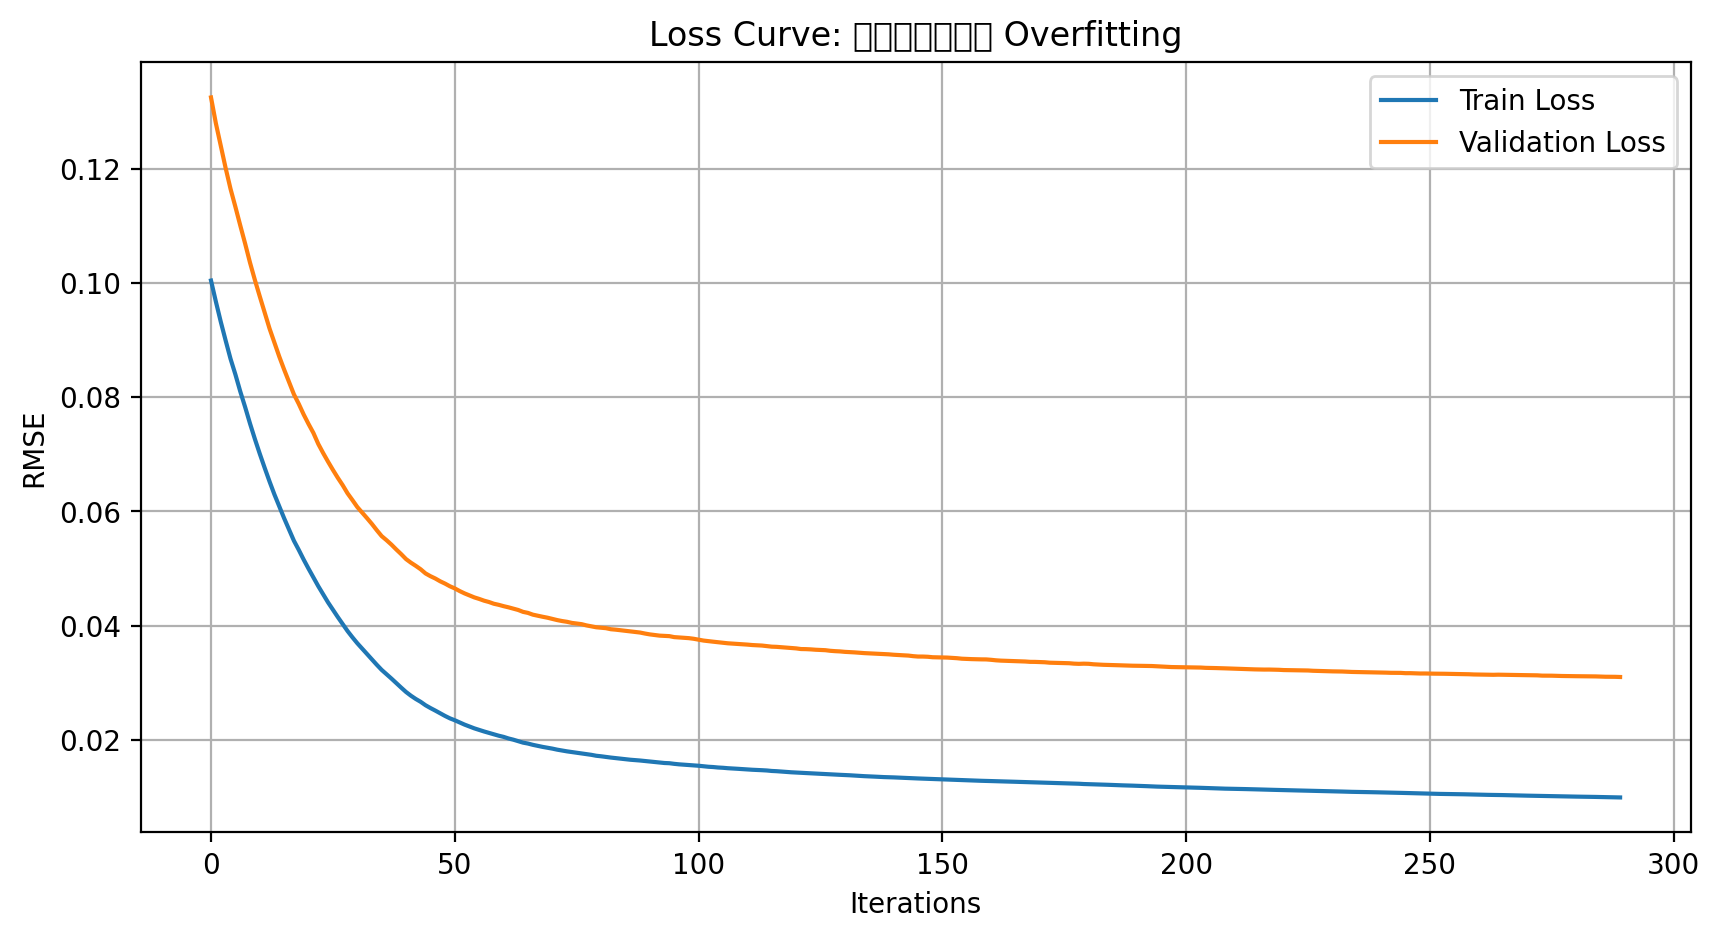

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train3, y_train3,
                    eval_set=(X_test3, y_test3),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train3, y_train3, X_test3, y_test3)

# **EC**

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,Temperature\n(֯C)_lag_1,Temperature\n(֯C)_lag_2,Temperature\n(֯C)_lag_3,Temperature\n(֯C)_lag_4,Temperature\n(֯C)_lag_5,Temperature\n(֯C)_lag_6,...,DO\n(mg/L)_lag_5,DO\n(mg/L)_lag_6,DO\n(mg/L)_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
date_time,,,,,,,,,,,,,,,,,,,,,
2014-05-05,31.747917,501.199898,4.301528,7.620000,31.693750,31.678415,31.137960,30.569691,30.001423,29.433154,...,6.754846,7.346309,7.757047,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638,9.276510
2014-05-06,31.799965,501.199898,4.414688,7.693785,31.747917,31.693750,31.678415,31.137960,30.569691,30.001423,...,6.163383,6.754846,7.346309,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638
2014-05-07,31.775764,501.199898,4.339514,7.719306,31.799965,31.747917,31.693750,31.678415,31.137960,30.569691,...,5.571919,6.163383,6.754846,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181
2014-05-08,31.948542,501.199898,4.385625,7.705069,31.775764,31.799965,31.747917,31.693750,31.678415,31.137960,...,4.928164,5.571919,6.163383,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725
2014-05-09,32.087292,501.199898,4.356528,7.682674,31.948542,31.775764,31.799965,31.747917,31.693750,31.678415,...,4.448542,4.928164,5.571919,7.705069,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000,31.311667,31.264444,31.348333,31.361736,31.442431,31.555000,...,2.706875,2.588125,2.585417,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-22,31.287986,345.090278,2.114375,3.080000,31.365139,31.311667,31.264444,31.348333,31.361736,31.442431,...,2.654931,2.706875,2.588125,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-23,31.137361,338.798611,2.126111,3.080000,31.287986,31.365139,31.311667,31.264444,31.348333,31.361736,...,2.618611,2.654931,2.706875,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000


In [ ]:
X = df[['Conductivity\n(uS/cm)_lag_1','Conductivity\n(uS/cm)_lag_2','Conductivity\n(uS/cm)_lag_3','Conductivity\n(uS/cm)_lag_4','Conductivity\n(uS/cm)_lag_5','Conductivity\n(uS/cm)_lag_6','Conductivity\n(uS/cm)_lag_7']]
y = df["Conductivity\n(uS/cm)"]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
X

,Conductivity\n(uS/cm)_lag_1,Conductivity\n(uS/cm)_lag_2,Conductivity\n(uS/cm)_lag_3,Conductivity\n(uS/cm)_lag_4,Conductivity\n(uS/cm)_lag_5,Conductivity\n(uS/cm)_lag_6,Conductivity\n(uS/cm)_lag_7
date_time,,,,,,,
2014-05-05,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-06,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-07,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-08,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-09,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
...,...,...,...,...,...,...,...
2024-07-21,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858,0.054915
2024-07-22,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858
2024-07-23,0.046390,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240


In [ ]:
split_at = int(len(X) * 0.7)

## no.1

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]

[I 2025-04-17 15:23:19,258] A new study created in memory with name: no-name-18991063-bb8e-4522-959a-8cd1b21b9d8f
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.0980853	test: 0.0652703	best: 0.0652703 (0)	total: 727us	remaining: 202ms
100:	learn: 0.0241494	test: 0.0172531	best: 0.0172127 (99)	total: 55.1ms	remaining: 96.6ms
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.01713717183
bestIteration = 108

Shrink model to first 109 iterations.

Test set performance:
R2: 0.9182790765825599
MAE: 0.00785461271926574
RMSE: 0.017137171929330418
MSE: 0.0002936826617354304


ความสำคัญของตัวแปร:
                        Feature  Importance
0  Conductivity\n(uS/cm)_lag_1   67.519541
1  Conductivity\n(uS/cm)_lag_2   16.139934
5  Conductivity\n(uS/cm)_lag_6    3.987207
2  Conductivity\n(uS/cm)_lag_3    3.795886
3  Conductivity\n(uS/cm)_lag_4    3.459383
6  Conductivity\n(uS/cm)_lag_7    2.554591
4  Conductivity\n(uS/cm)_lag_5    2.543457


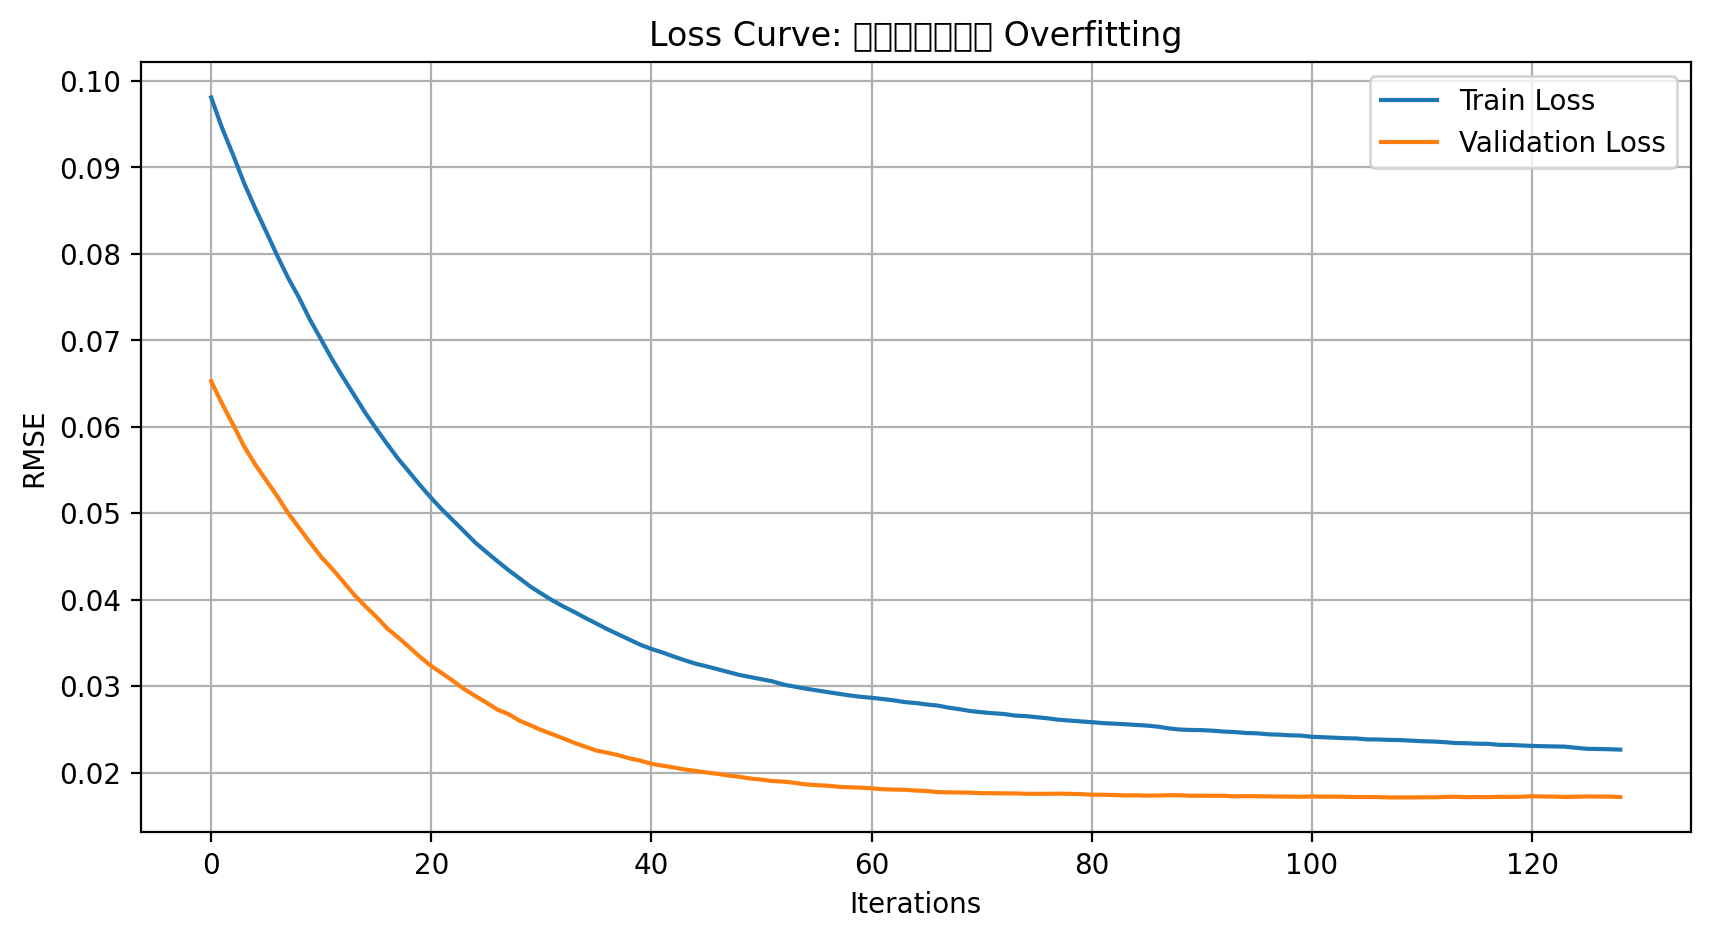

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train1, y_train1,
                    eval_set=(X_test1, y_test1),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train1, y_train1, X_test1, y_test1)

## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

In [ ]:
X

,Conductivity\n(uS/cm)_lag_1,Conductivity\n(uS/cm)_lag_2,Conductivity\n(uS/cm)_lag_3,Conductivity\n(uS/cm)_lag_4,Conductivity\n(uS/cm)_lag_5,Conductivity\n(uS/cm)_lag_6,Conductivity\n(uS/cm)_lag_7
date_time,,,,,,,
2014-05-05,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-06,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-07,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-08,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-09,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
...,...,...,...,...,...,...,...
2024-07-21,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858,0.054915
2024-07-22,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858
2024-07-23,0.046390,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240


[I 2025-04-17 15:24:09,947] A new study created in memory with name: no-name-6abee594-ffc0-49e3-bafb-9b7c55bc88bc
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.0997258	test: 0.0600476	best: 0.0600476 (0)	total: 678us	remaining: 188ms
100:	learn: 0.0248522	test: 0.0159941	best: 0.0159941 (100)	total: 56.5ms	remaining: 99ms
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.0155296237
bestIteration = 160

Shrink model to first 161 iterations.

Test set performance:
R2: 0.9077459986727018
MAE: 0.006709343636132915
RMSE: 0.015529623714624491
MSE: 0.00024116921271782738


ความสำคัญของตัวแปร:
                        Feature  Importance
0  Conductivity\n(uS/cm)_lag_1   62.751628
1  Conductivity\n(uS/cm)_lag_2   14.315379
2  Conductivity\n(uS/cm)_lag_3    7.897481
5  Conductivity\n(uS/cm)_lag_6    4.576477
6  Conductivity\n(uS/cm)_lag_7    3.894545
3  Conductivity\n(uS/cm)_lag_4    3.418534
4  Conductivity\n(uS/cm)_lag_5    3.145956


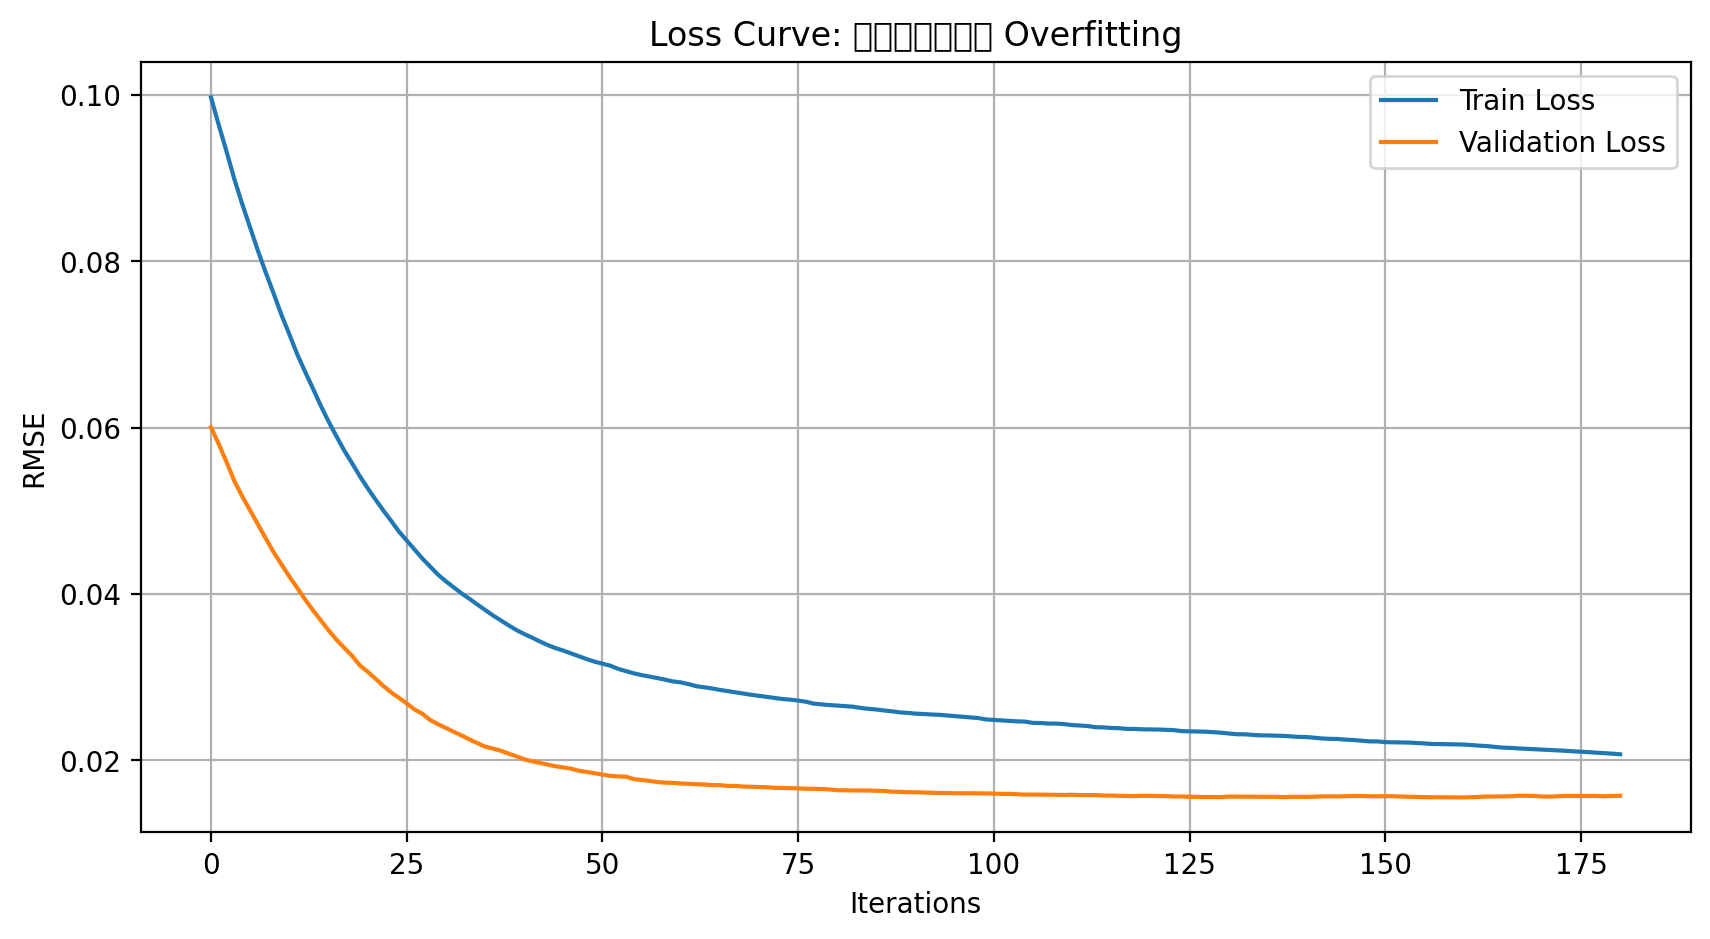

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train2, y_train2,
                    eval_set=(X_test2, y_test2),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train2, y_train2, X_test2, y_test2)

## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

[I 2025-04-17 15:24:30,940] A new study created in memory with name: no-name-0ab66eba-f424-4a9e-9d3f-e6820f8b2e44
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.1004909	test: 0.0568739	best: 0.0568739 (0)	total: 682us	remaining: 189ms
100:	learn: 0.0248962	test: 0.0154238	best: 0.0154238 (100)	total: 54.1ms	remaining: 94.7ms
200:	learn: 0.0198711	test: 0.0145309	best: 0.0144361 (197)	total: 109ms	remaining: 41.6ms
277:	learn: 0.0175085	test: 0.0141353	best: 0.0141353 (277)	total: 150ms	remaining: 0us

bestTest = 0.01413532228
bestIteration = 277


Test set performance:
R2: 0.9120448913308071
MAE: 0.006001861542195744
RMSE: 0.014135322280873074
MSE: 0.00019980733598414673


ความสำคัญของตัวแปร:
                        Feature  Importance
0  Conductivity\n(uS/cm)_lag_1   61.897185
1  Conductivity\n(uS/cm)_lag_2   15.460641
2  Conductivity\n(uS/cm)_lag_3    6.189189
6  Conductivity\n(uS/cm)_lag_7    5.149387
5  Conductivity\n(uS/cm)_lag_6    3.975313
4  Conductivity\n(uS/cm)_lag_5    3.764684
3  Conductivity\n(uS/cm)_lag_4    3.563602


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

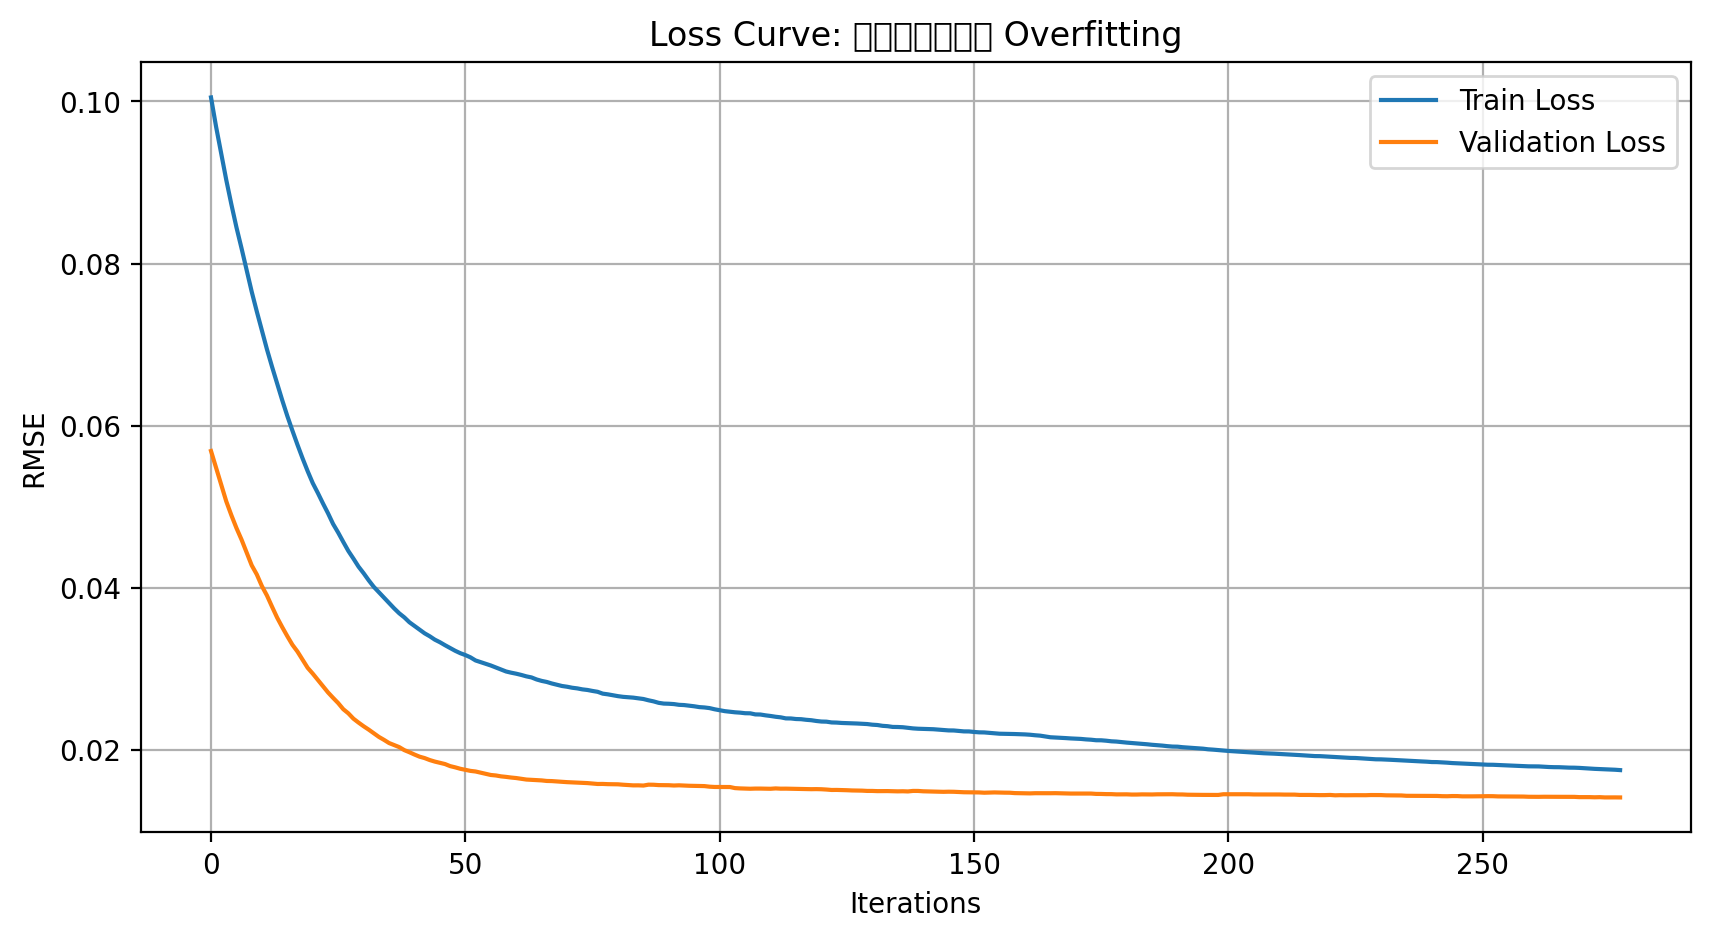

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train3, y_train3,
                    eval_set=(X_test3, y_test3),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train3, y_train3, X_test3, y_test3)

# **DO**

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,Temperature\n(֯C)_lag_1,Temperature\n(֯C)_lag_2,Temperature\n(֯C)_lag_3,Temperature\n(֯C)_lag_4,Temperature\n(֯C)_lag_5,Temperature\n(֯C)_lag_6,...,DO\n(mg/L)_lag_5,DO\n(mg/L)_lag_6,DO\n(mg/L)_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
date_time,,,,,,,,,,,,,,,,,,,,,
2014-05-05,31.747917,501.199898,4.301528,7.620000,31.693750,31.678415,31.137960,30.569691,30.001423,29.433154,...,6.754846,7.346309,7.757047,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638,9.276510
2014-05-06,31.799965,501.199898,4.414688,7.693785,31.747917,31.693750,31.678415,31.137960,30.569691,30.001423,...,6.163383,6.754846,7.346309,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638
2014-05-07,31.775764,501.199898,4.339514,7.719306,31.799965,31.747917,31.693750,31.678415,31.137960,30.569691,...,5.571919,6.163383,6.754846,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181
2014-05-08,31.948542,501.199898,4.385625,7.705069,31.775764,31.799965,31.747917,31.693750,31.678415,31.137960,...,4.928164,5.571919,6.163383,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725
2014-05-09,32.087292,501.199898,4.356528,7.682674,31.948542,31.775764,31.799965,31.747917,31.693750,31.678415,...,4.448542,4.928164,5.571919,7.705069,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000,31.311667,31.264444,31.348333,31.361736,31.442431,31.555000,...,2.706875,2.588125,2.585417,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-22,31.287986,345.090278,2.114375,3.080000,31.365139,31.311667,31.264444,31.348333,31.361736,31.442431,...,2.654931,2.706875,2.588125,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-23,31.137361,338.798611,2.126111,3.080000,31.287986,31.365139,31.311667,31.264444,31.348333,31.361736,...,2.618611,2.654931,2.706875,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000


In [ ]:
X = df[['DO\n(mg/L)_lag_1','DO\n(mg/L)_lag_2','DO\n(mg/L)_lag_3','DO\n(mg/L)_lag_4','DO\n(mg/L)_lag_5','DO\n(mg/L)_lag_6','DO\n(mg/L)_lag_7']]
y = df["DO\n(mg/L)"]

In [ ]:
X

,DO\n(mg/L)_lag_1,DO\n(mg/L)_lag_2,DO\n(mg/L)_lag_3,DO\n(mg/L)_lag_4,DO\n(mg/L)_lag_5,DO\n(mg/L)_lag_6,DO\n(mg/L)_lag_7
date_time,,,,,,,
2014-05-05,4.448542,4.928164,5.571919,6.163383,6.754846,7.346309,7.757047
2014-05-06,4.301528,4.448542,4.928164,5.571919,6.163383,6.754846,7.346309
2014-05-07,4.414688,4.301528,4.448542,4.928164,5.571919,6.163383,6.754846
2014-05-08,4.339514,4.414688,4.301528,4.448542,4.928164,5.571919,6.163383
2014-05-09,4.385625,4.339514,4.414688,4.301528,4.448542,4.928164,5.571919
...,...,...,...,...,...,...,...
2024-07-21,2.276389,2.389653,2.618611,2.654931,2.706875,2.588125,2.585417
2024-07-22,2.146181,2.276389,2.389653,2.618611,2.654931,2.706875,2.588125
2024-07-23,2.114375,2.146181,2.276389,2.389653,2.618611,2.654931,2.706875


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
split_at = int(len(X) * 0.7)

## no.1

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]

[I 2025-04-17 15:26:53,609] A new study created in memory with name: no-name-ad85bcc0-4291-47a2-8d1e-20ea639ca69d
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.1146250	test: 0.1859463	best: 0.1859463 (0)	total: 1.25ms	remaining: 336ms
100:	learn: 0.0361157	test: 0.0510799	best: 0.0510799 (100)	total: 304ms	remaining: 506ms
200:	learn: 0.0311337	test: 0.0450264	best: 0.0450256 (199)	total: 424ms	remaining: 143ms
268:	learn: 0.0278988	test: 0.0437408	best: 0.0436986 (265)	total: 471ms	remaining: 0us

bestTest = 0.04369862873
bestIteration = 265

Shrink model to first 266 iterations.

Test set performance:
R2: 0.9483892831795023
MAE: 0.027894006915120288
RMSE: 0.04369862894946753
MSE: 0.0019095701720632417


ความสำคัญของตัวแปร:
             Feature  Importance
0  DO\n(mg/L)_lag_1   57.350623
1  DO\n(mg/L)_lag_2   18.793064
2  DO\n(mg/L)_lag_3    8.274907
3  DO\n(mg/L)_lag_4    5.057361
4  DO\n(mg/L)_lag_5    4.818319
6  DO\n(mg/L)_lag_7    3.194097
5  DO\n(mg/L)_lag_6    2.511630


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

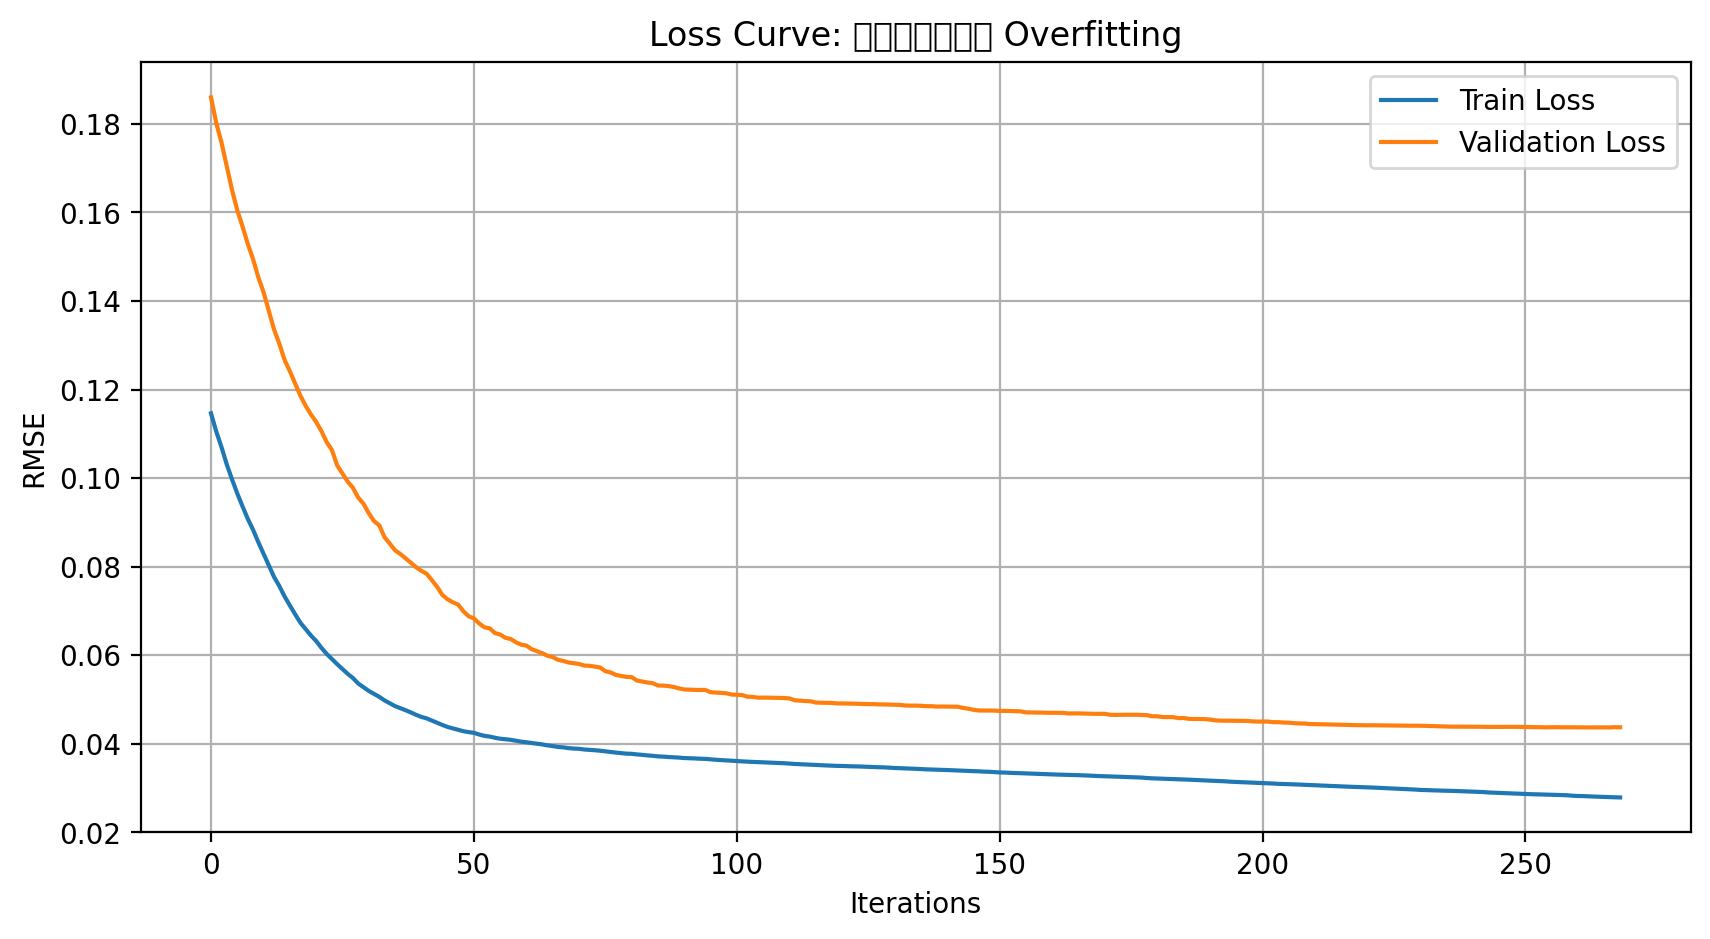

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train1, y_train1,
                    eval_set=(X_test1, y_test1),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train1, y_train1, X_test1, y_test1)

## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

[I 2025-04-17 15:27:31,031] A new study created in memory with name: no-name-0c9cc5df-f9eb-451b-9fc8-e0cc84494ba8
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.1142703	test: 0.1865798	best: 0.1865798 (0)	total: 838us	remaining: 225ms
100:	learn: 0.0359729	test: 0.0508664	best: 0.0508664 (100)	total: 74ms	remaining: 123ms
200:	learn: 0.0309334	test: 0.0449257	best: 0.0449257 (200)	total: 144ms	remaining: 48.6ms
268:	learn: 0.0276632	test: 0.0436054	best: 0.0436046 (266)	total: 193ms	remaining: 0us

bestTest = 0.04360463565
bestIteration = 266

Shrink model to first 267 iterations.

Test set performance:
R2: 0.9489595271805598
MAE: 0.027992020948012
RMSE: 0.04360463586850809
MSE: 0.001901364269225182


ความสำคัญของตัวแปร:
             Feature  Importance
0  DO\n(mg/L)_lag_1   58.221479
1  DO\n(mg/L)_lag_2   17.203844
2  DO\n(mg/L)_lag_3    8.621366
3  DO\n(mg/L)_lag_4    5.086637
4  DO\n(mg/L)_lag_5    4.628350
6  DO\n(mg/L)_lag_7    3.172970
5  DO\n(mg/L)_lag_6    3.065355


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

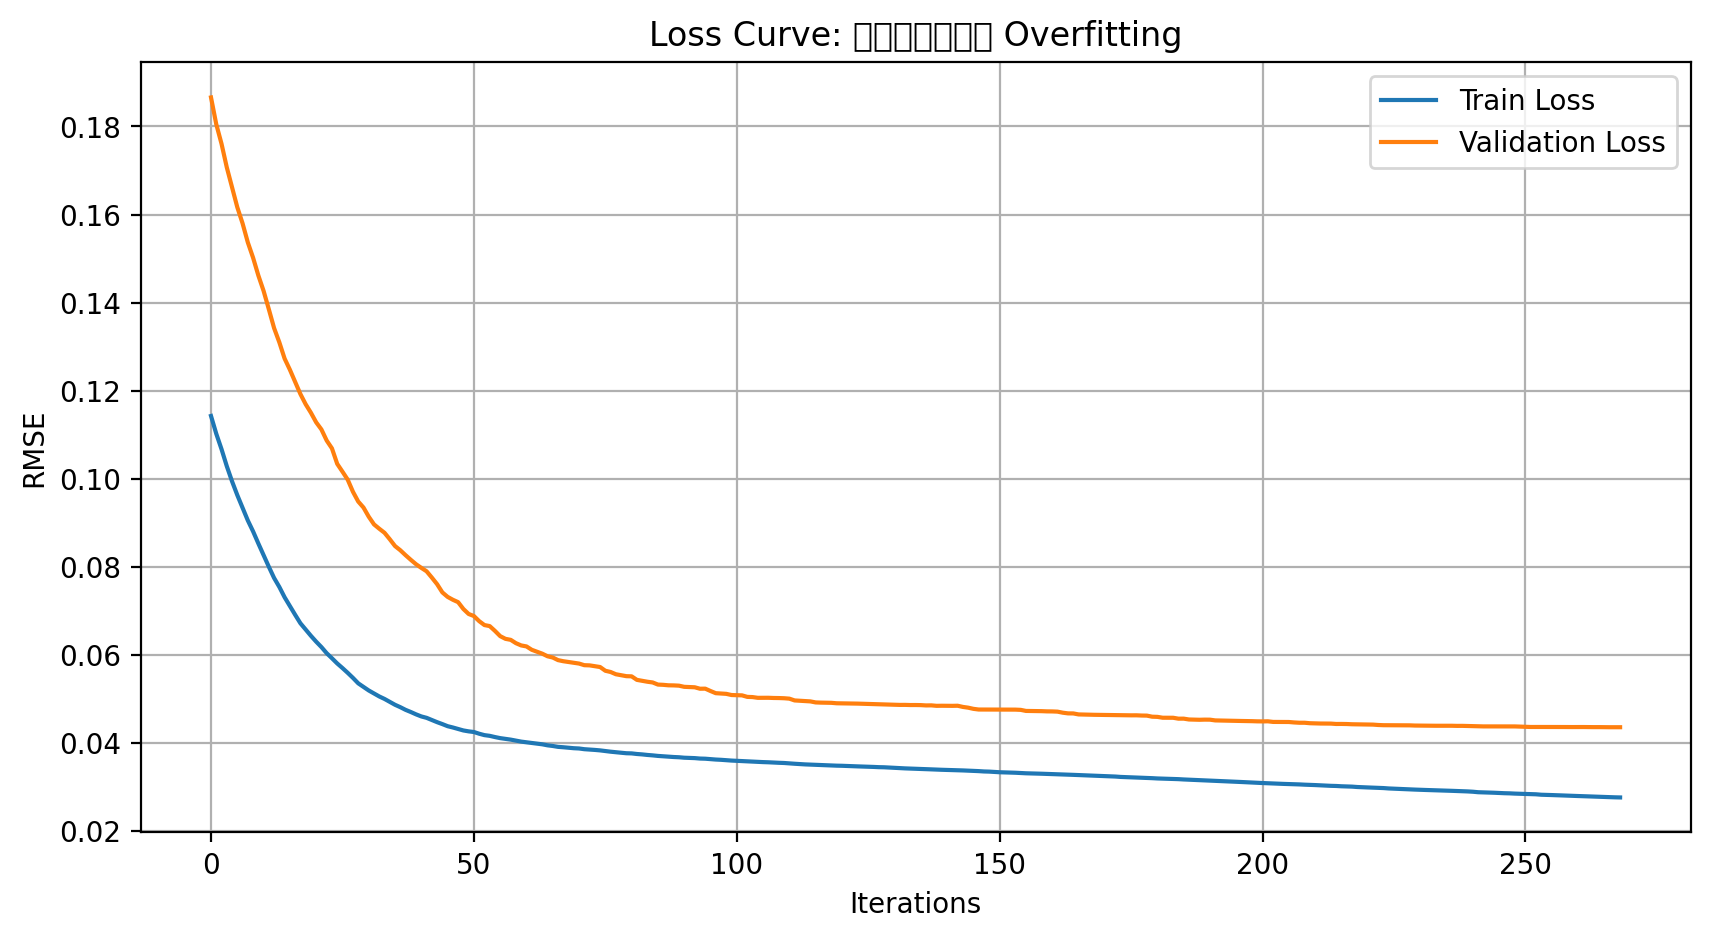

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train2, y_train2,
                    eval_set=(X_test2, y_test2),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train2, y_train2, X_test2, y_test2)

## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

[I 2025-04-17 15:27:51,999] A new study created in memory with name: no-name-6216dac0-feb8-4ba2-b104-6f1da59d1daa
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.1121822	test: 0.1893335	best: 0.1893335 (0)	total: 832us	remaining: 223ms
100:	learn: 0.0352413	test: 0.0525465	best: 0.0525465 (100)	total: 71ms	remaining: 118ms
200:	learn: 0.0301691	test: 0.0468679	best: 0.0468679 (200)	total: 145ms	remaining: 49ms
268:	learn: 0.0270823	test: 0.0455953	best: 0.0455929 (267)	total: 197ms	remaining: 0us

bestTest = 0.04559289754
bestIteration = 267

Shrink model to first 268 iterations.

Test set performance:
R2: 0.9458866627279934
MAE: 0.029802315833545832
RMSE: 0.04559289780866217
MSE: 0.002078712330591112


ความสำคัญของตัวแปร:
             Feature  Importance
0  DO\n(mg/L)_lag_1   56.749785
1  DO\n(mg/L)_lag_2   17.881554
2  DO\n(mg/L)_lag_3    9.285767
3  DO\n(mg/L)_lag_4    5.517178
4  DO\n(mg/L)_lag_5    3.783463
6  DO\n(mg/L)_lag_7    3.427817
5  DO\n(mg/L)_lag_6    3.354436


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

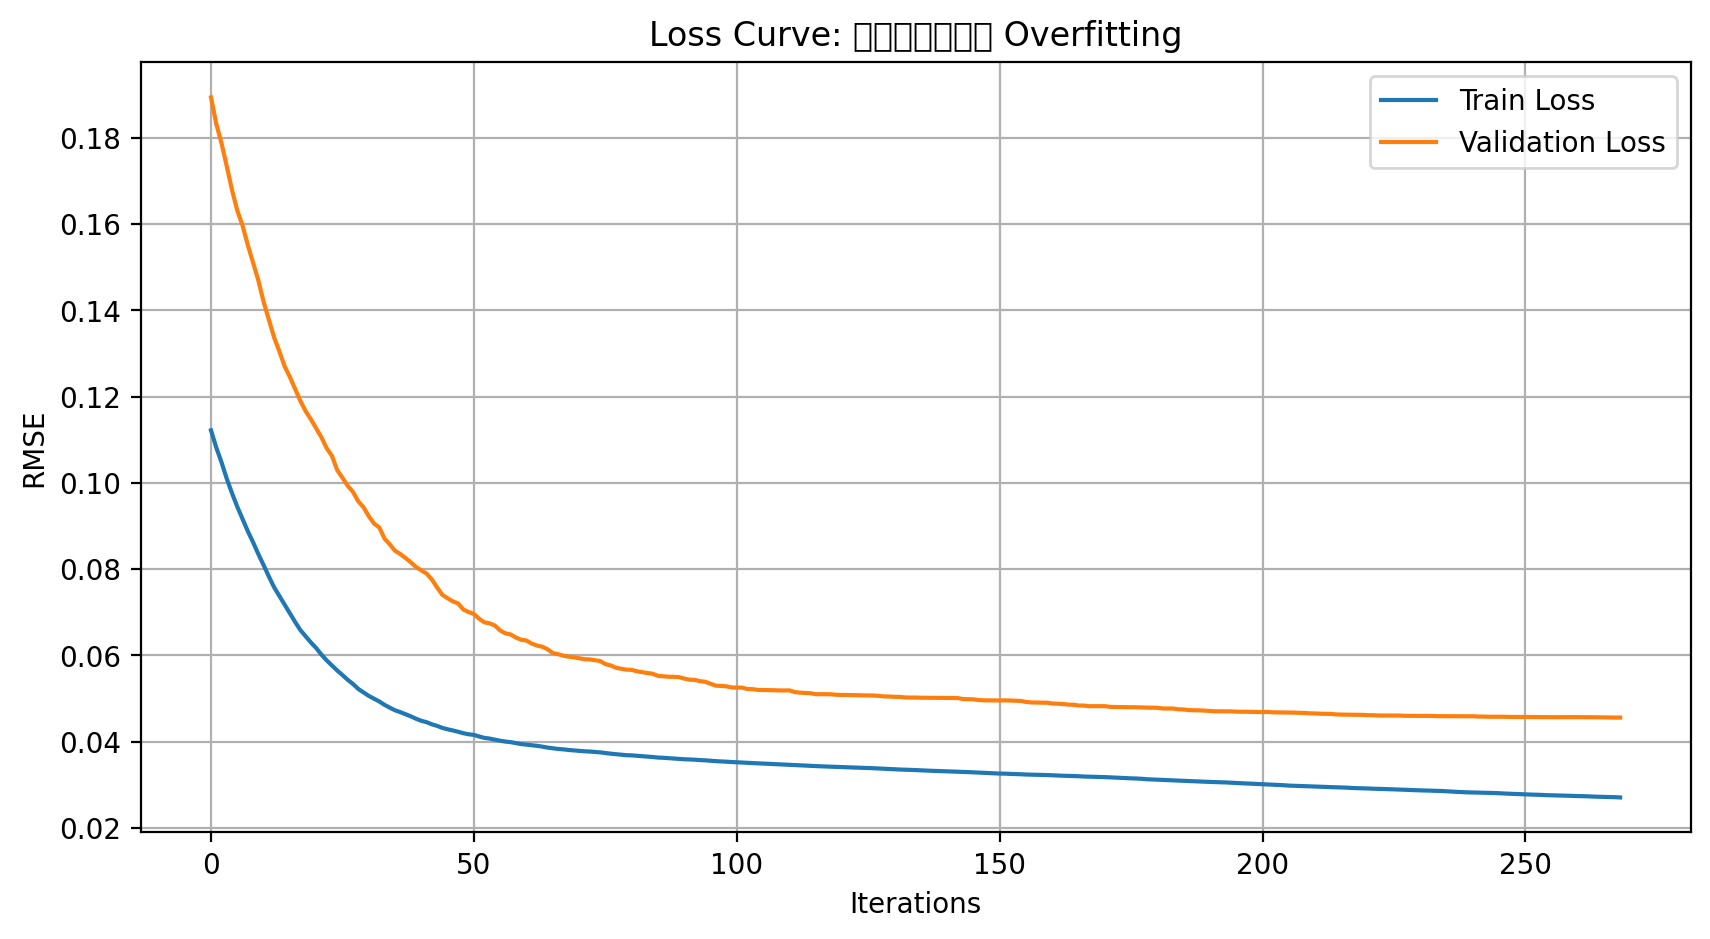

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train3, y_train3,
                    eval_set=(X_test3, y_test3),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train3, y_train3, X_test3, y_test3)

# **pH**

In [ ]:
df['pH']

,pH
date_time,
2014-05-05,7.620000
2014-05-06,7.693785
2014-05-07,7.719306
2014-05-08,7.705069
2014-05-09,7.682674
...,...
2024-07-21,3.080000
2024-07-22,3.080000
2024-07-23,3.080000


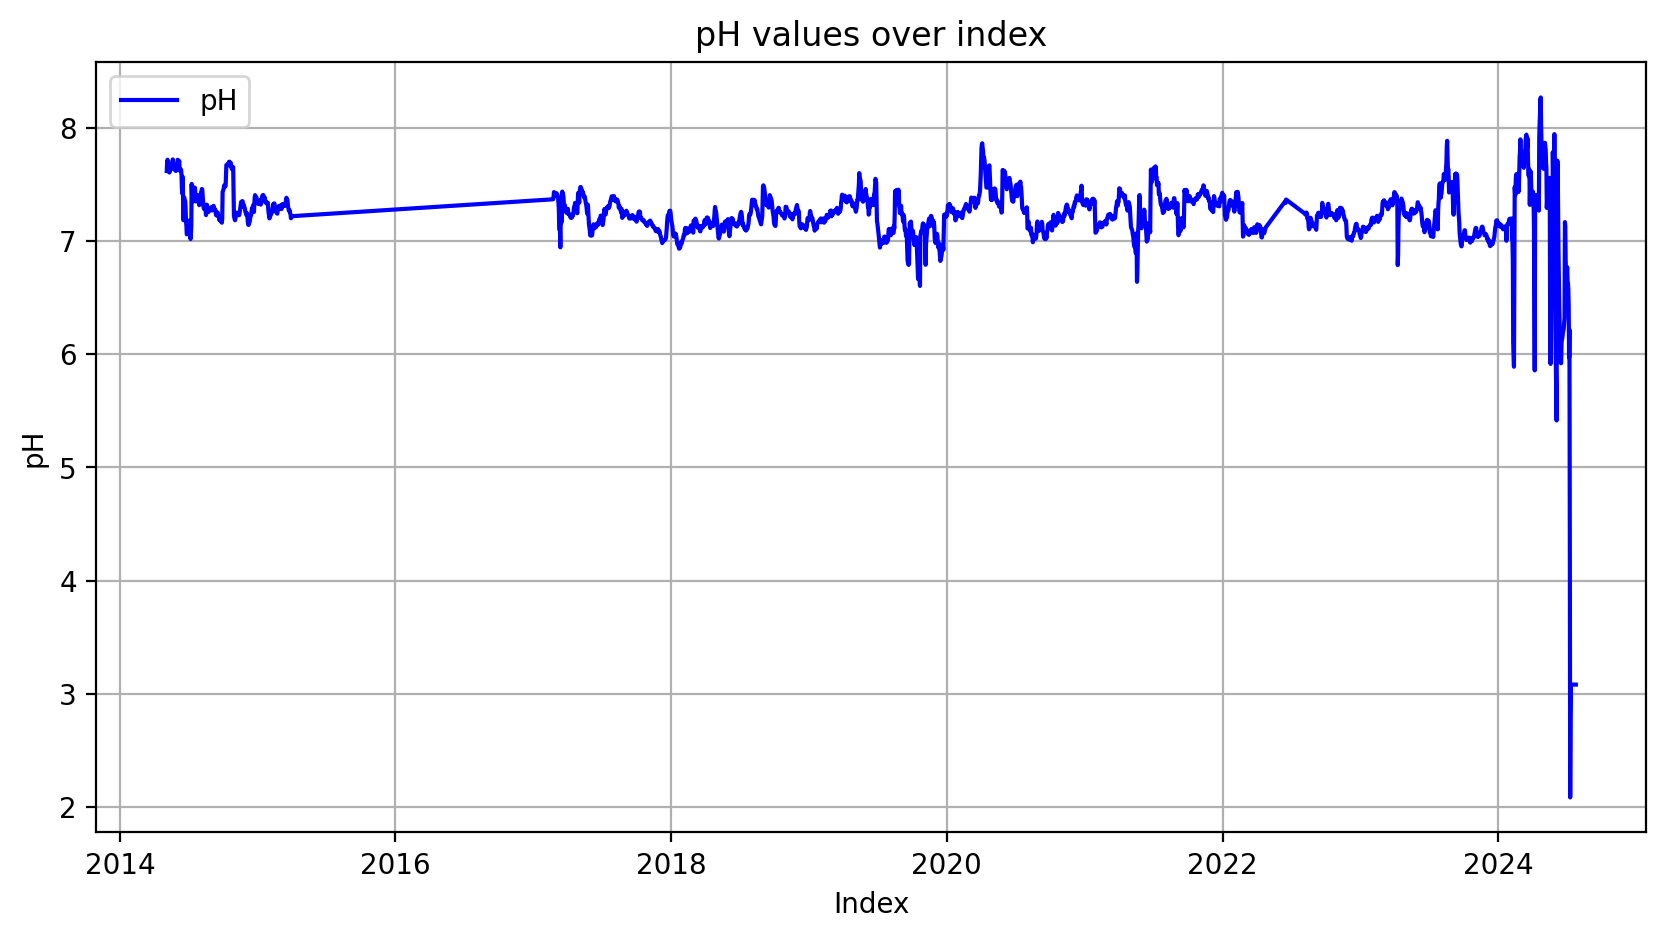

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['pH'], label='pH', color='blue')
plt.title('pH values over index')
plt.xlabel('Index')
plt.ylabel('pH')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
ph_2024 = df.loc['2024-01-01':'2024-12-31', 'pH']

In [ ]:
ph_2024

,pH
date_time,
2024-01-01,7.147083
2024-01-02,7.136042
2024-01-03,7.132778
2024-01-04,7.140486
2024-01-05,7.155625
...,...
2024-07-21,3.080000
2024-07-22,3.080000
2024-07-23,3.080000


In [ ]:
df_filtered = df[df['pH'] >= 4]

In [ ]:
df_filtered

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,Temperature\n(֯C)_lag_1,Temperature\n(֯C)_lag_2,Temperature\n(֯C)_lag_3,Temperature\n(֯C)_lag_4,Temperature\n(֯C)_lag_5,Temperature\n(֯C)_lag_6,...,DO\n(mg/L)_lag_5,DO\n(mg/L)_lag_6,DO\n(mg/L)_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
date_time,,,,,,,,,,,,,,,,,,,,,
2014-05-05,31.747917,501.199898,4.301528,7.620000,31.693750,31.678415,31.137960,30.569691,30.001423,29.433154,...,6.754846,7.346309,7.757047,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638,9.276510
2014-05-06,31.799965,501.199898,4.414688,7.693785,31.747917,31.693750,31.678415,31.137960,30.569691,30.001423,...,6.163383,6.754846,7.346309,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638
2014-05-07,31.775764,501.199898,4.339514,7.719306,31.799965,31.747917,31.693750,31.678415,31.137960,30.569691,...,5.571919,6.163383,6.754846,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181
2014-05-08,31.948542,501.199898,4.385625,7.705069,31.775764,31.799965,31.747917,31.693750,31.678415,31.137960,...,4.928164,5.571919,6.163383,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725
2014-05-09,32.087292,501.199898,4.356528,7.682674,31.948542,31.775764,31.799965,31.747917,31.693750,31.678415,...,4.448542,4.928164,5.571919,7.705069,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-05,31.274931,412.486111,1.668333,6.579583,31.314653,31.356875,31.489861,31.441389,31.415833,31.367778,...,1.810208,2.178542,2.468194,6.630556,6.648125,6.770139,6.704583,6.702847,6.730417,6.830694
2024-07-06,31.412986,396.027778,1.876875,6.432639,31.274931,31.314653,31.356875,31.489861,31.441389,31.415833,...,2.005278,1.810208,2.178542,6.579583,6.630556,6.648125,6.770139,6.704583,6.702847,6.730417
2024-07-07,31.568542,397.638889,1.674931,5.970347,31.412986,31.274931,31.314653,31.356875,31.489861,31.441389,...,2.285694,2.005278,1.810208,6.432639,6.579583,6.630556,6.648125,6.770139,6.704583,6.702847


In [ ]:
X = df_filtered[['pH_lag_1','pH_lag_2','pH_lag_3','pH_lag_4','pH_lag_5','pH_lag_6','pH_lag_7']]
y = df_filtered["pH"]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
#X_scaled = pd.DataFrame(X_scaled, columns=columns_to_scale)
#X = pd.concat([X_scaled, X_not_scaled.reset_index(drop=True)], axis=1)

X = pd.DataFrame(X_scaled, columns=X.columns)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
X

,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
0,0.764613,0.804453,0.922342,1.000000,1.000000,1.000000,1.000000
1,0.772347,0.764613,0.804453,0.887909,0.899207,0.908436,0.940215
2,0.798189,0.772347,0.764613,0.774421,0.798414,0.816872,0.854125
3,0.807127,0.798189,0.772347,0.736068,0.696365,0.725308,0.768035
4,0.802141,0.807127,0.798189,0.743514,0.661877,0.632603,0.681945
...,...,...,...,...,...,...,...
3714,0.425808,0.431962,0.474695,0.434871,0.390513,0.362349,0.366653
3715,0.407956,0.425808,0.431962,0.456974,0.391039,0.354756,0.340686
3716,0.356491,0.407956,0.425808,0.415836,0.410914,0.355234,0.333547
3717,0.194580,0.356491,0.407956,0.409912,0.373922,0.373289,0.333996


In [ ]:
y

,pH
date_time,
2014-05-05,0.831173
2014-05-06,0.850338
2014-05-07,0.856966
2014-05-08,0.853269
2014-05-09,0.847452
...,...
2024-07-05,0.560942
2024-07-06,0.522776
2024-07-07,0.402703


In [ ]:
split_at = int(len(X) * 0.7)

## no.1

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]

[I 2025-04-17 15:32:38,288] A new study created in memory with name: no-name-4bc41186-9e2c-489f-a2a6-acb1438c7913
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.0355362	test: 0.0744259	best: 0.0744259 (0)	total: 597us	remaining: 158ms
100:	learn: 0.0119702	test: 0.0521266	best: 0.0521266 (100)	total: 49.7ms	remaining: 80.7ms
200:	learn: 0.0100815	test: 0.0484757	best: 0.0484682 (199)	total: 95.9ms	remaining: 30.5ms
264:	learn: 0.0090154	test: 0.0469538	best: 0.0469538 (264)	total: 126ms	remaining: 0us

bestTest = 0.04695384773
bestIteration = 264


Test set performance:
R2: 0.6091346830873886
MAE: 0.016221310159934648
RMSE: 0.04695384785945288
MSE: 0.0022046638288086475


ความสำคัญของตัวแปร:
     Feature  Importance
0  pH_lag_1   41.392581
1  pH_lag_2   31.031969
2  pH_lag_3    8.796660
5  pH_lag_6    6.199701
3  pH_lag_4    4.806437
6  pH_lag_7    4.798804
4  pH_lag_5    2.973848


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

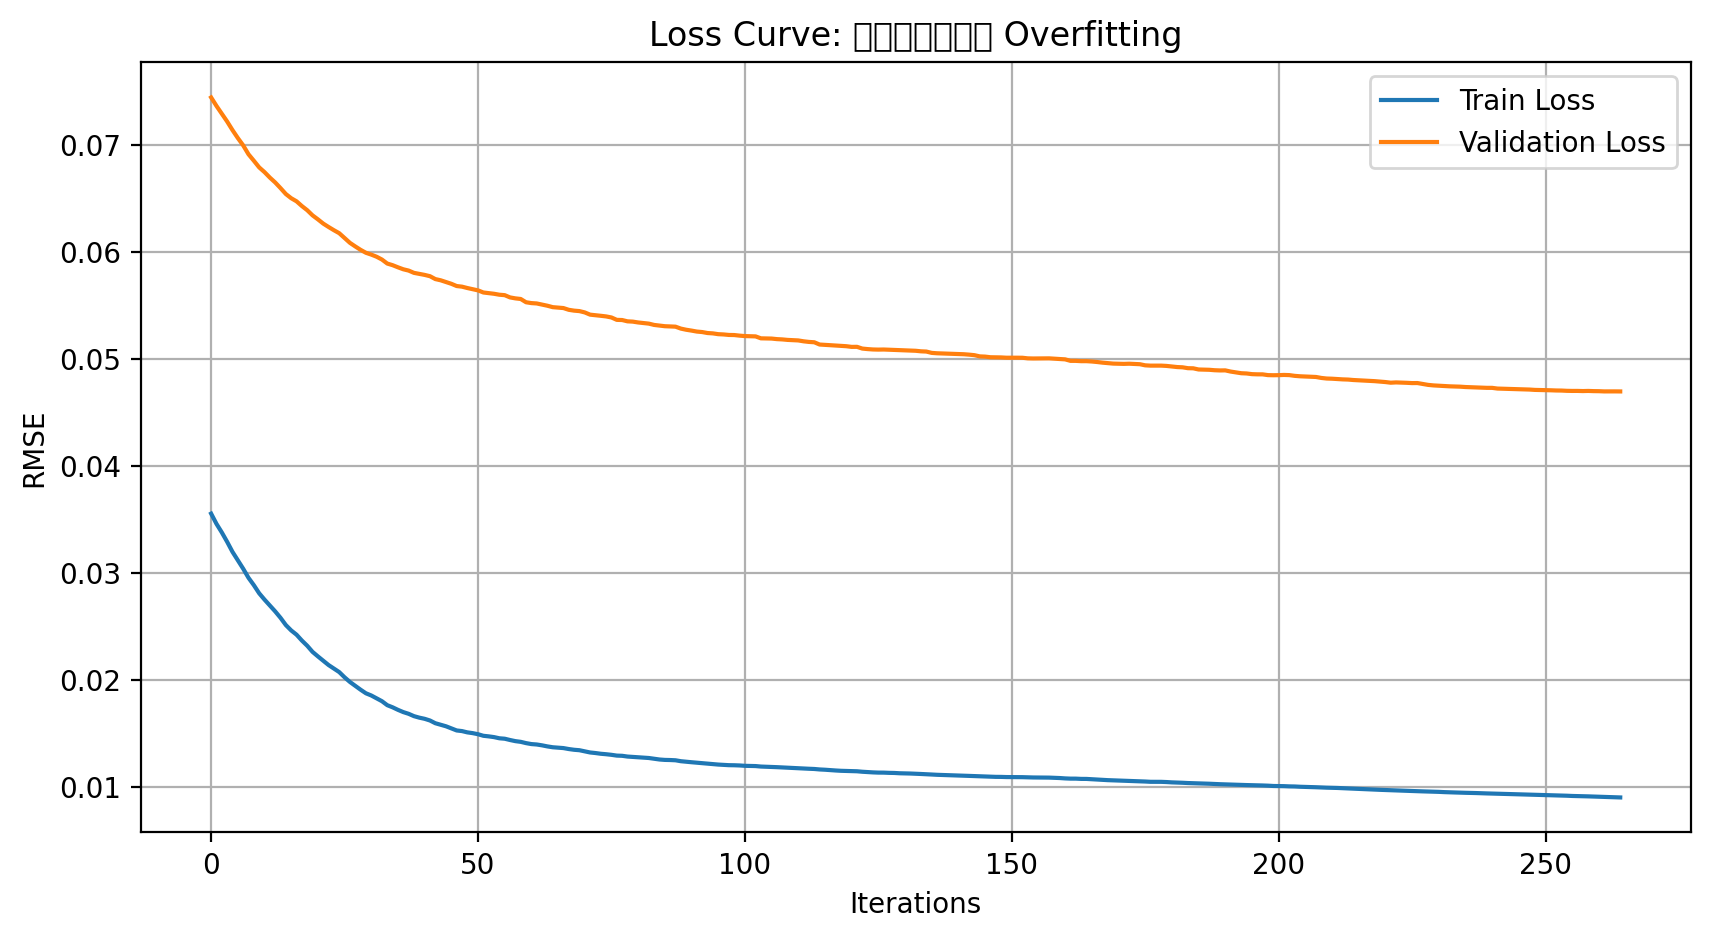

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train1, y_train1,
                    eval_set=(X_test1, y_test1),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train1, y_train1, X_test1, y_test1)

In [ ]:
# 1. ย้อนการสเกลของค่าที่ทำนายและค่าจริง
y_pred_scaled = model.predict(X_test1)
y_pred_original = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# สมมติว่าคุณมีค่าจริง y_test1 ที่ถูกสเกลไว้ด้วย คุณควรย้อนการแปลงค่าจริงเหล่านั้น
y_test_original = scaler.inverse_transform(y_test1)

# 2. สร้าง DataFrame เพื่อความสะดวกในการเปรียบเทียบ
results_df = pd.DataFrame({
    "Predicted": y_pred_original.flatten(),
    "Actual": y_test_original.flatten()
})

# 3. พิมพ์ผลลัพธ์การเปรียบเทียบ
print("การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:")
print(results_df)

การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:
      Predicted    Actual
0      7.133063  7.097153
1      7.112292  7.106042
2      7.115845  7.109792
3      7.100653  7.078264
4      7.084937  7.419549
...         ...       ...
1111   6.813004  6.579583
1112   6.813004  6.432639
1113   6.813004  5.970347
1114   6.813004  6.217419
1115   6.813004  4.419900

[1116 rows x 2 columns]


## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

[I 2025-04-17 15:33:29,238] A new study created in memory with name: no-name-8e17f110-b968-4df0-9d86-95c986c22f8d
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.0352297	test: 0.0747763	best: 0.0747763 (0)	total: 531us	remaining: 140ms
100:	learn: 0.0120035	test: 0.0520058	best: 0.0520058 (100)	total: 50.2ms	remaining: 81.5ms
200:	learn: 0.0103059	test: 0.0494149	best: 0.0494149 (200)	total: 98.5ms	remaining: 31.4ms
264:	learn: 0.0092484	test: 0.0484313	best: 0.0484313 (264)	total: 143ms	remaining: 0us

bestTest = 0.04843132023
bestIteration = 264


Test set performance:
R2: 0.5889144231205341
MAE: 0.01644569792459309
RMSE: 0.04843132032499279
MSE: 0.00234559278842206


ความสำคัญของตัวแปร:
     Feature  Importance
0  pH_lag_1   44.595510
1  pH_lag_2   30.123649
2  pH_lag_3    8.667337
3  pH_lag_4    4.618571
6  pH_lag_7    4.452841
5  pH_lag_6    4.205280
4  pH_lag_5    3.336812


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

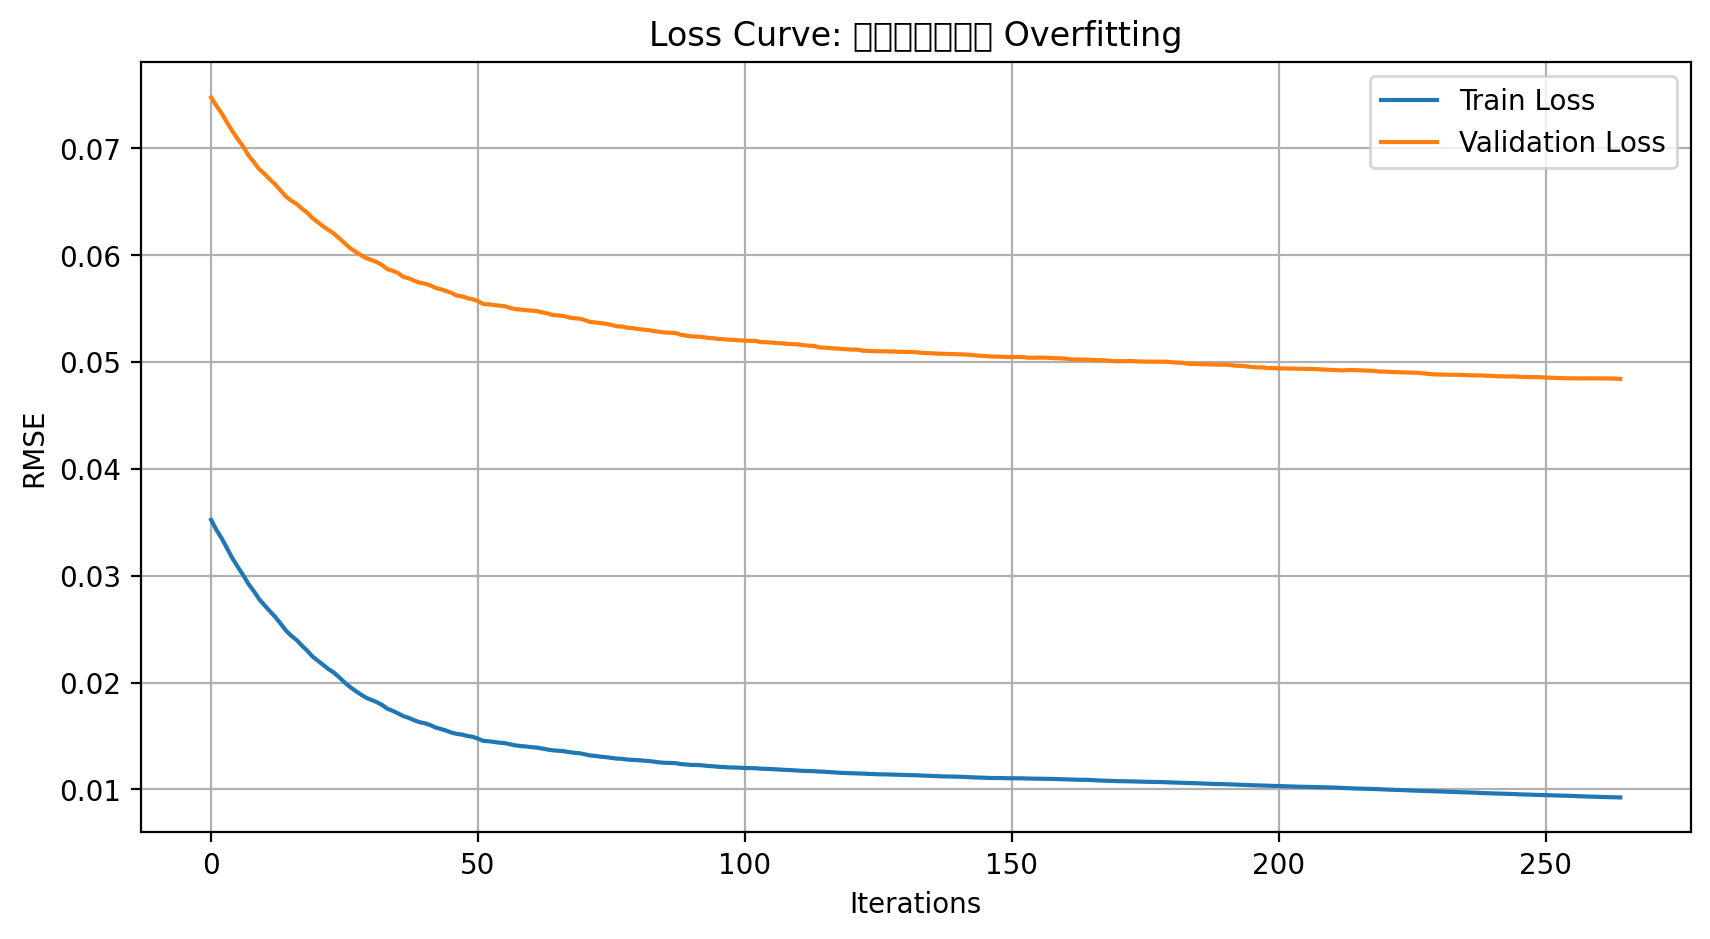

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train2, y_train2,
                    eval_set=(X_test2, y_test2),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train2, y_train2, X_test2, y_test2)

## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

[I 2025-04-17 15:33:59,280] A new study created in memory with name: no-name-4d00113a-13f9-4638-a28b-76e51e52e6b7
<ipython-input-111-71b323fa1718>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
<ipython-input-111-71b323fa1718>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-2, 10.0),  # เพิ่ม regularization ขึ้นเยอะ
<ipython-input-111-71b323fa1718>:8: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'r

0:	learn: 0.0338778	test: 0.0762601	best: 0.0762601 (0)	total: 550us	remaining: 145ms
100:	learn: 0.0116170	test: 0.0522652	best: 0.0522652 (100)	total: 47ms	remaining: 76.4ms
200:	learn: 0.0099366	test: 0.0493360	best: 0.0493360 (200)	total: 92.7ms	remaining: 29.5ms
264:	learn: 0.0089330	test: 0.0481048	best: 0.0481048 (264)	total: 121ms	remaining: 0us

bestTest = 0.04810479272
bestIteration = 264


Test set performance:
R2: 0.6118011433726145
MAE: 0.016746818977980547
RMSE: 0.048104792761497754
MSE: 0.002314071086626647


ความสำคัญของตัวแปร:
     Feature  Importance
0  pH_lag_1   42.469488
1  pH_lag_2   35.005004
2  pH_lag_3    7.432613
4  pH_lag_5    3.939012
3  pH_lag_4    3.897485
6  pH_lag_7    3.800499
5  pH_lag_6    3.455899


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

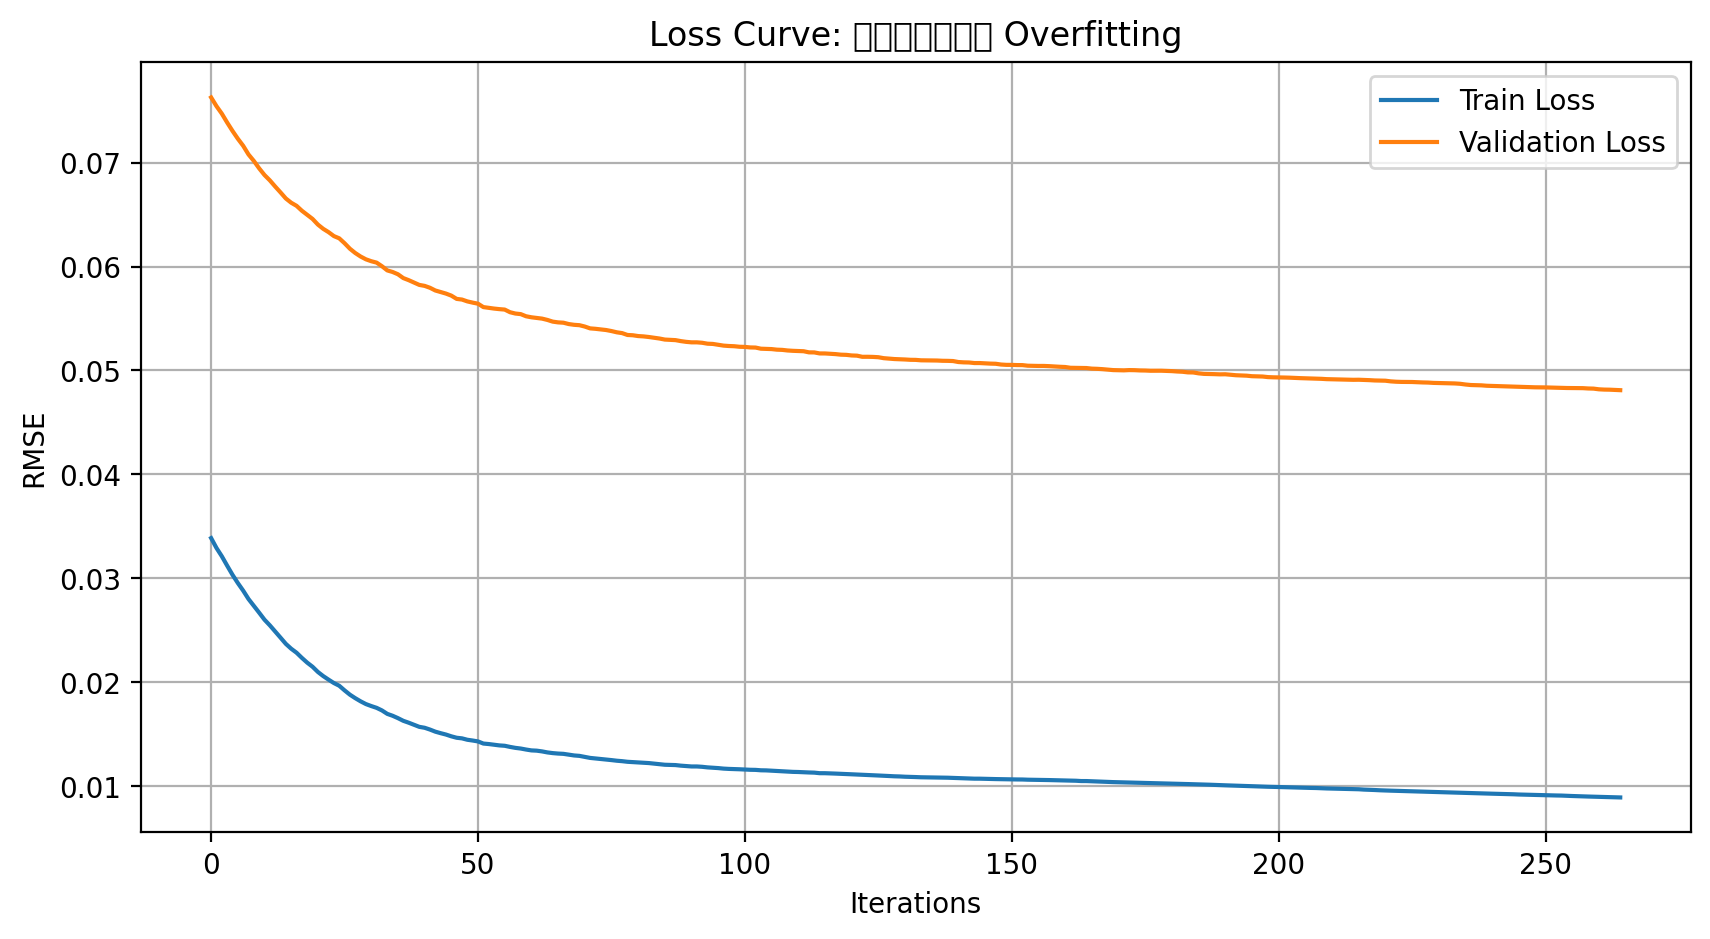

In [ ]:
cat_features = []

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = 0
best_params['early_stopping_rounds'] = 20
best_params['verbose'] = 100

# ฝึกโมเดลและเก็บ train/test loss
model = CatBoostRegressor(**best_params)
history = model.fit(X_train3, y_train3,
                    eval_set=(X_test3, y_test3),
                    cat_features=cat_features,
                    use_best_model=True,
                    verbose=100,
                    plot=False)

regression_model(model, X_train3, y_train3, X_test3, y_test3)